# Simplified Causal Study Analysis

This notebook provides a streamlined interface for analyzing causal study results using the refactored visualization functions.

In [1]:
import os
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from datetime import datetime

# Import necessary functions
from causal_evaluation import load_study_results
from causal_visualization import generate_all_plots

# Filter out specific FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning, 
                       message="use_inf_as_na option is deprecated")
warnings.filterwarnings("ignore", category=FutureWarning, 
                       message="When grouping with a length-1 list-like")

## 1. Configuration

Set the paths and parameters for the analysis.

In [2]:
# Set the main study folder path
main_study_folder = "full_study_results_2025-04-05_14-00-23"

# Create a results folder for the analysis
results_folder = f"analysis_results_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
os.makedirs(results_folder, exist_ok=True)

# Optionally, specify which studies to analyze
# If None, all *_study folders in the main_study_folder will be processed
studies = None  # e.g., ['auto_study', 'cross_study', 'noise_study']

## 2. Load Data and Generate Plots

Load the study results and generate all plots.

Loading study results and generating all plots...
Detecting studies in folder...
Found studies: ['T_study', 'auto_study', 'cross_study', 'n_boot_study', 'noise_study']
Loading study results from full_study_results_2025-04-05_14-00-23...
Found 5 substudy folders
Processing substudy: T_study
  Processing parameter value: 1000.0
  Processing parameter value: 200.0
  Processing parameter value: 2500.0
  Processing parameter value: 300.0
  Processing parameter value: 400.0
  Processing parameter value: 500.0
  Processing parameter value: 5000.0
  Processing parameter value: 600.0
  Processing parameter value: 700.0
  Processing parameter value: 800.0
  Processing parameter value: 900.0
  Processing parameter value: 1000.0
  Processing parameter value: 200.0
  Processing parameter value: 2500.0
  Processing parameter value: 300.0
  Processing parameter value: 400.0
  Processing parameter value: 500.0
  Processing parameter value: 5000.0
  Processing parameter value: 600.0
  Processing parame

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  Generating overall estimation success rate plot...
Generating plots for T study...
  Generating estimation success rate plot...
  Generating error plots without CI...
  Generating effect comparison plots...
  Generating CI comparison plots...
  Generating bootstrap distribution plots...
    Processing param_val = 200.0
    Processing param_val = 700.0
    Processing param_val = 5000.0
  Generating adjustment set plots...
Generating plots for a study...
  Generating estimation success rate plot...
  Generating error plots without CI...
  Generating effect comparison plots...
  Generating CI comparison plots...


/home/blind_fish/shares/bht/Module/Abschluss/thesis/BaCode/causal_visualization.py:2624: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 7))


  Generating bootstrap distribution plots...
    Processing param_val = 0.01
    Processing param_val = 0.5257894736842105
    Processing param_val = 0.99
  Generating adjustment set plots...
Generating plots for c study...
  Generating estimation success rate plot...
  Generating error plots without CI...
  Generating effect comparison plots...
  Generating CI comparison plots...
  Generating bootstrap distribution plots...
    Processing param_val = 0.01
    Processing param_val = 0.5257894736842105
    Processing param_val = 0.99
  Generating adjustment set plots...
Generating plots for B study...
  Generating estimation success rate plot...
  Generating error plots without CI...
  Generating effect comparison plots...
  Generating CI comparison plots...
  Generating bootstrap distribution plots...
    Processing param_val = 10.0
    Processing param_val = 100.0
    Processing param_val = 500.0
  Generating adjustment set plots...
Generating plots for sigmaN study...
  Generating es

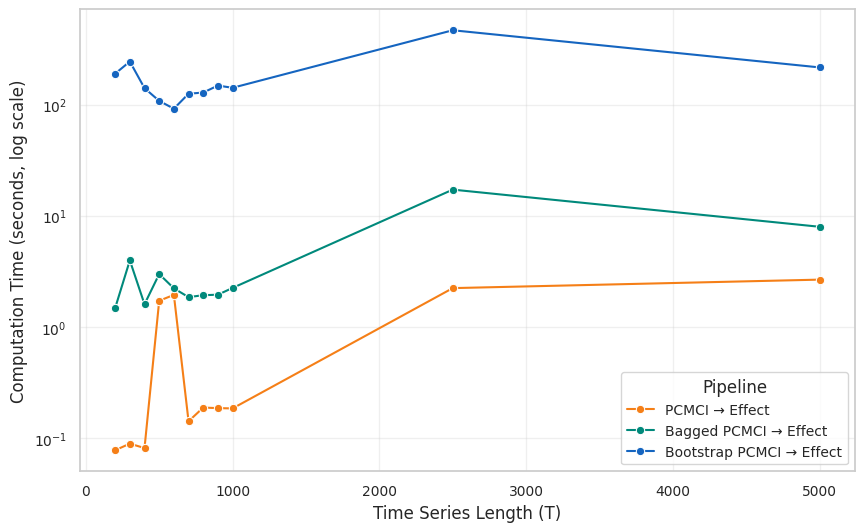

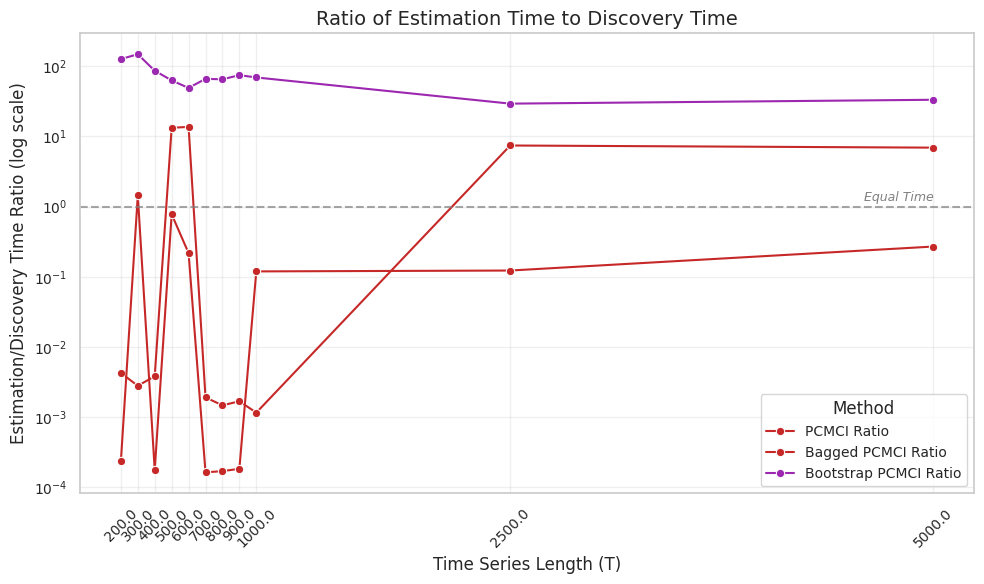

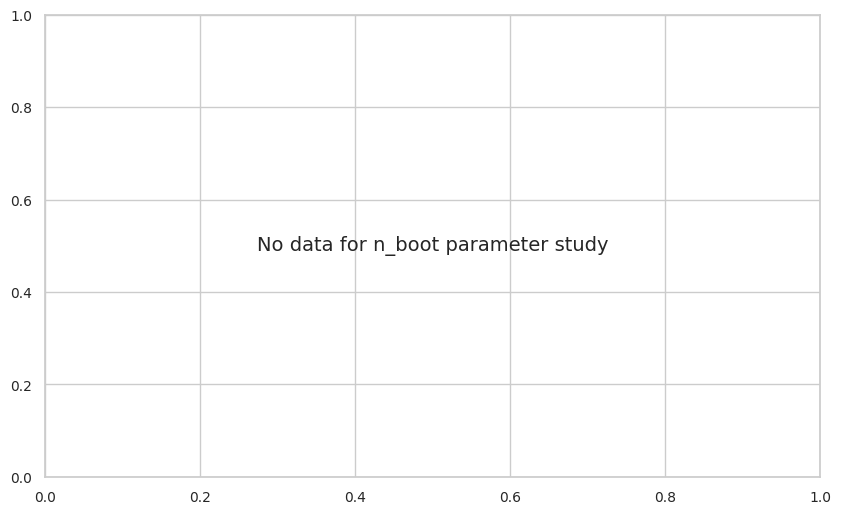

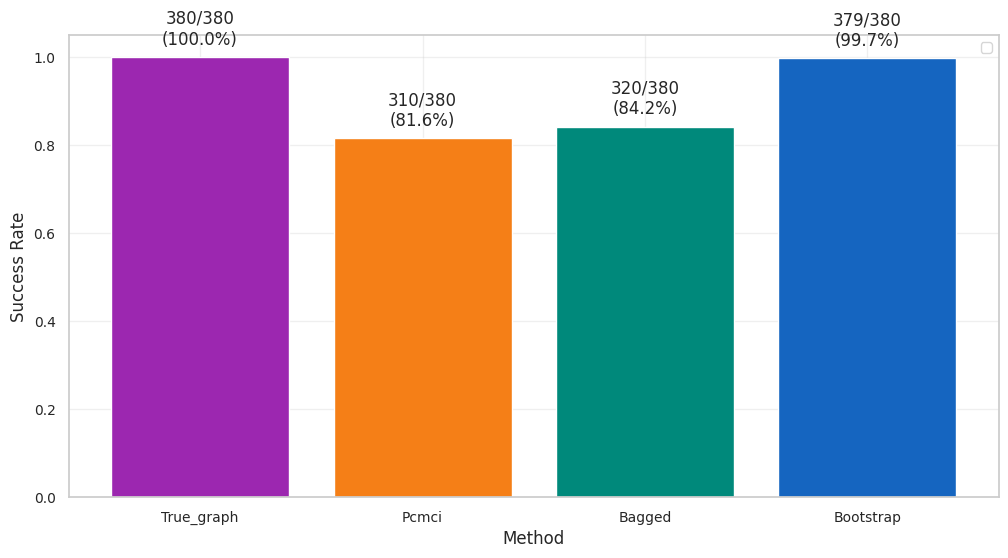

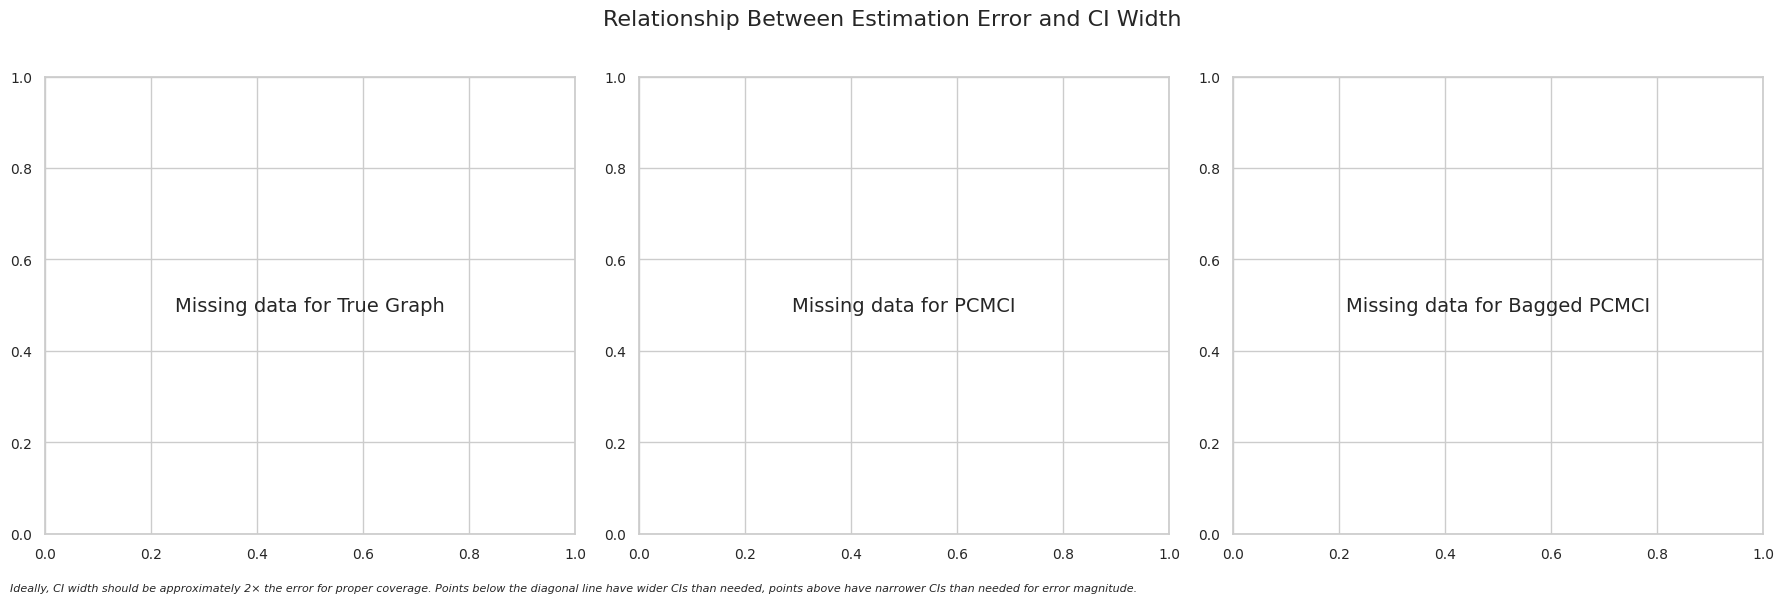

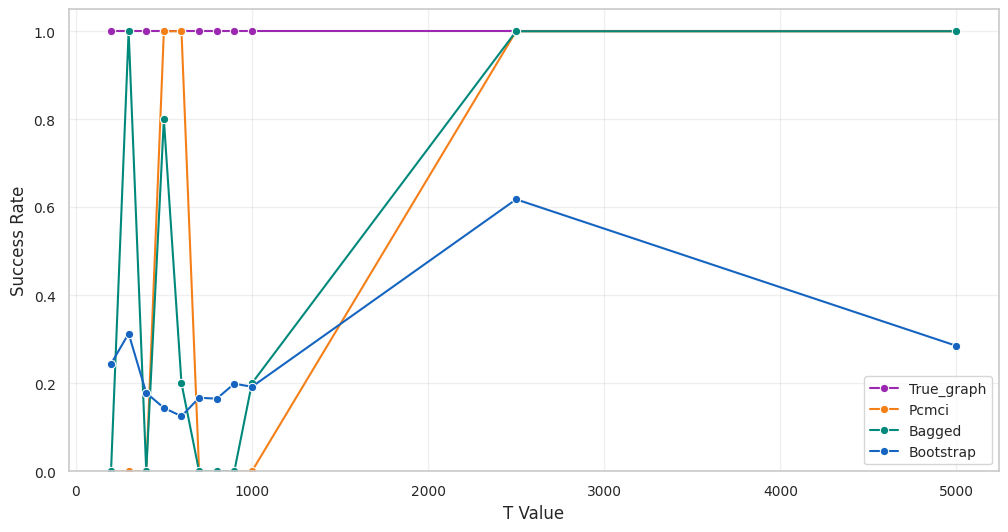

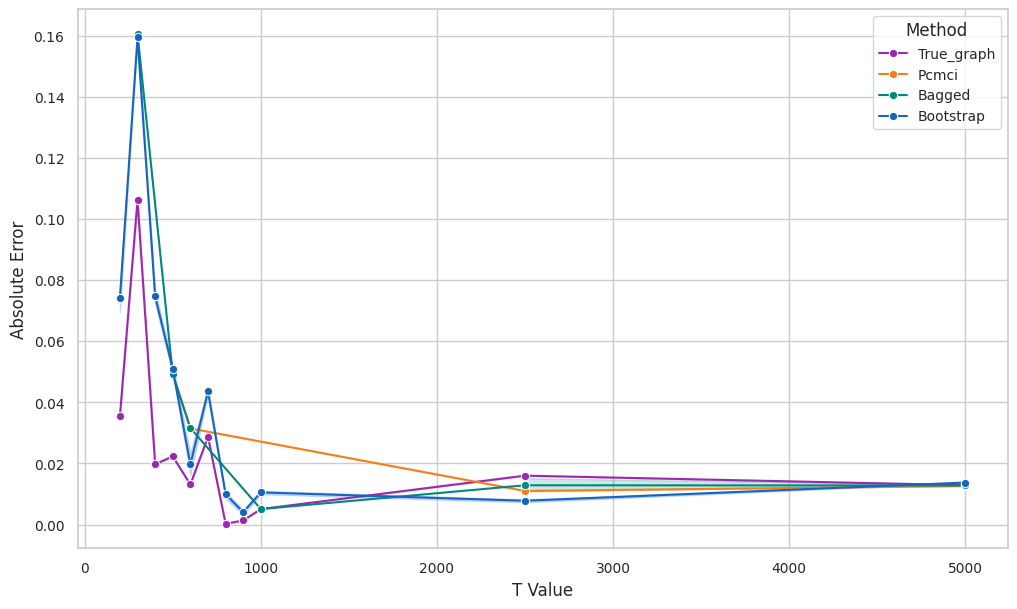

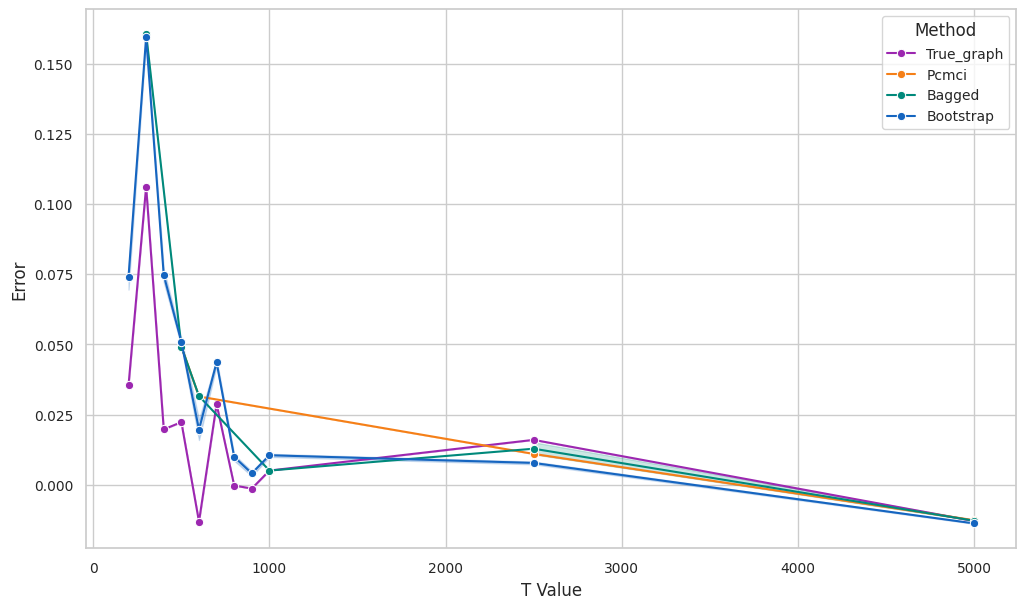

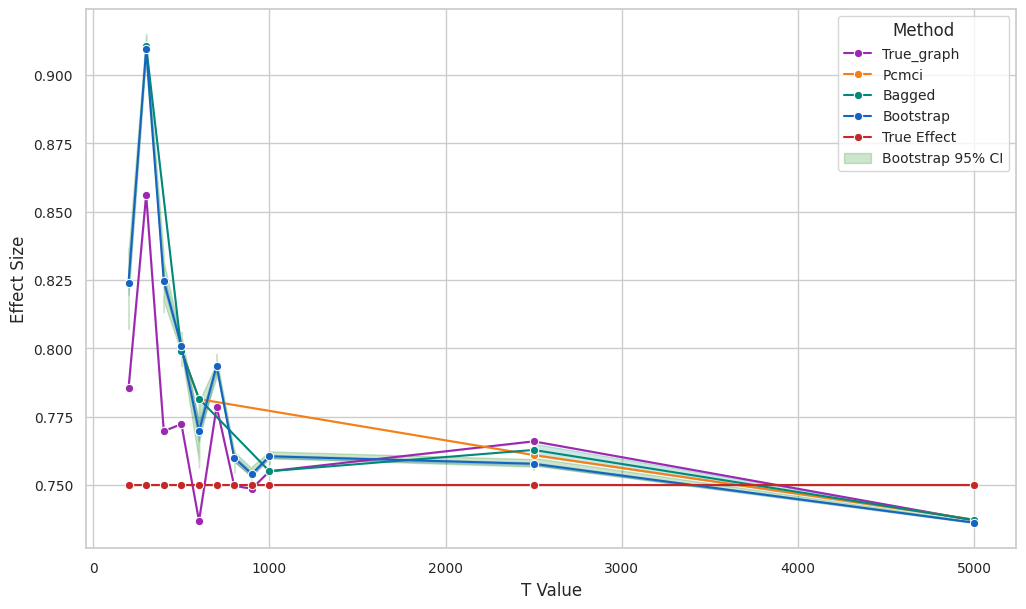

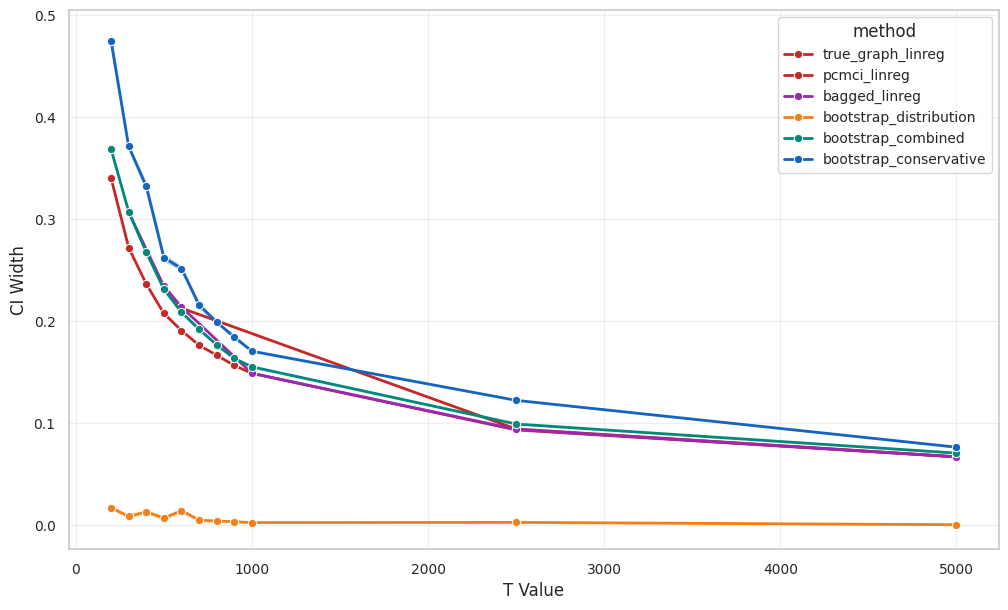

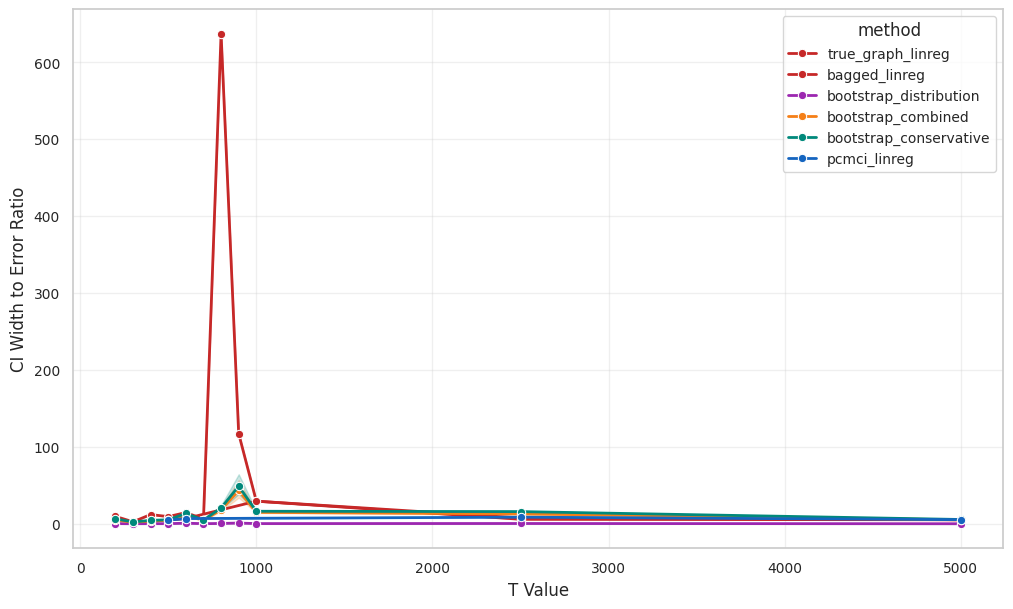

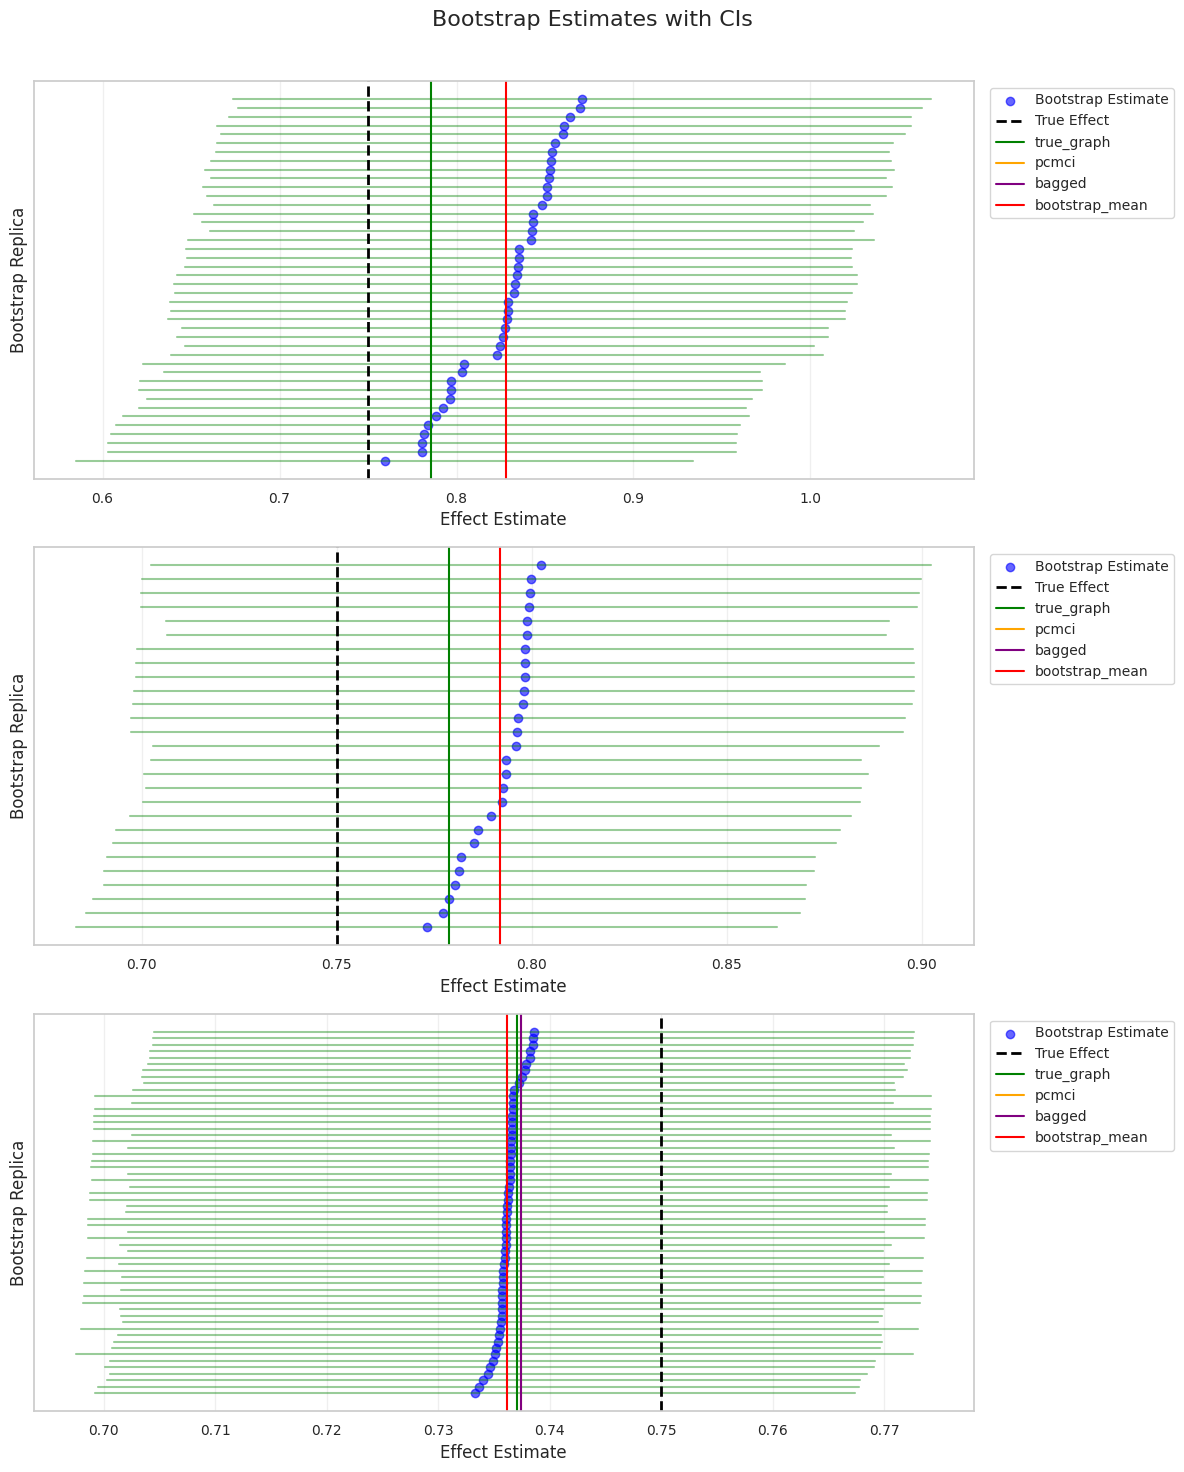

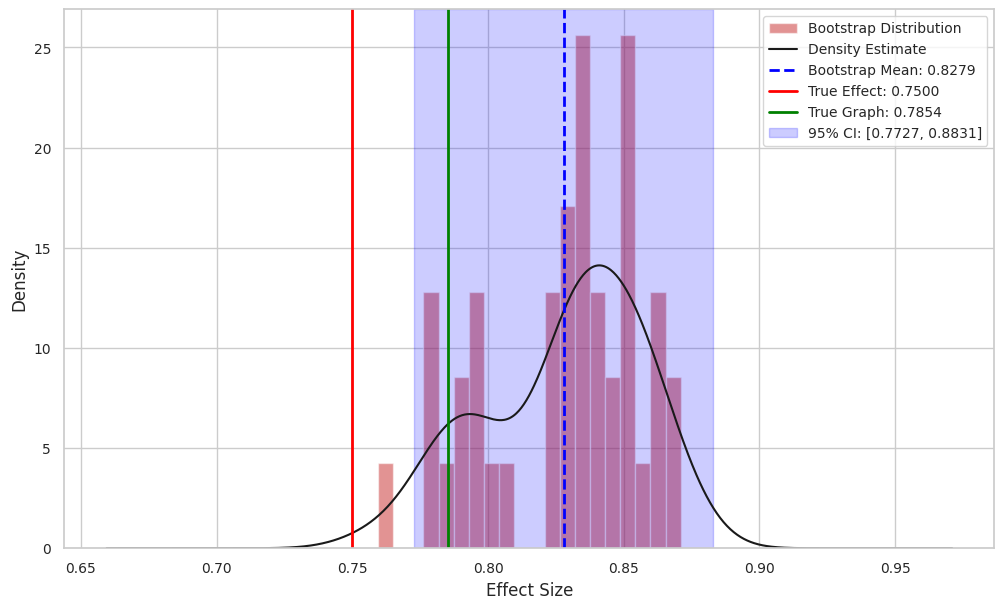

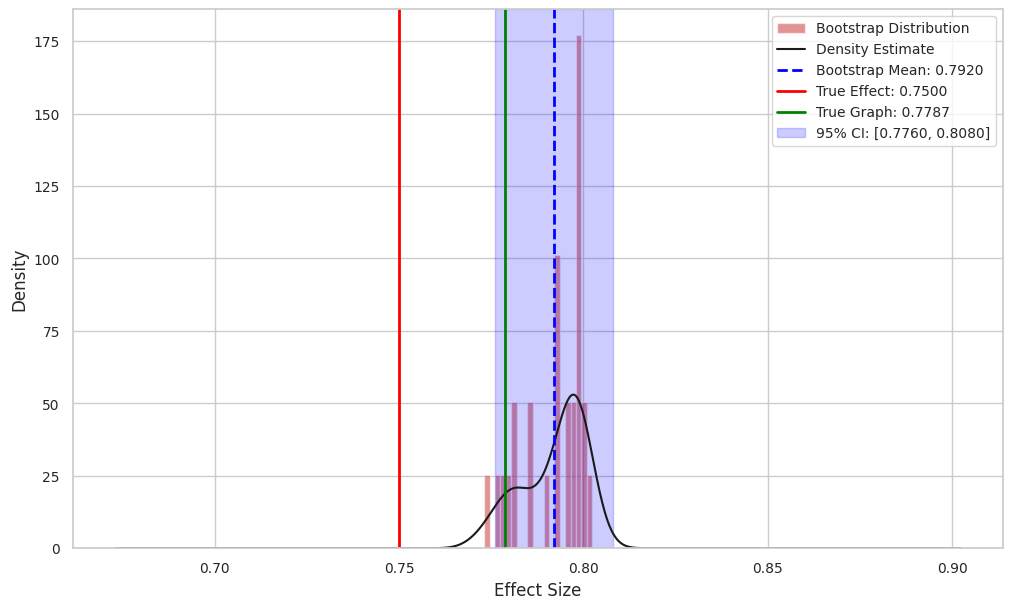

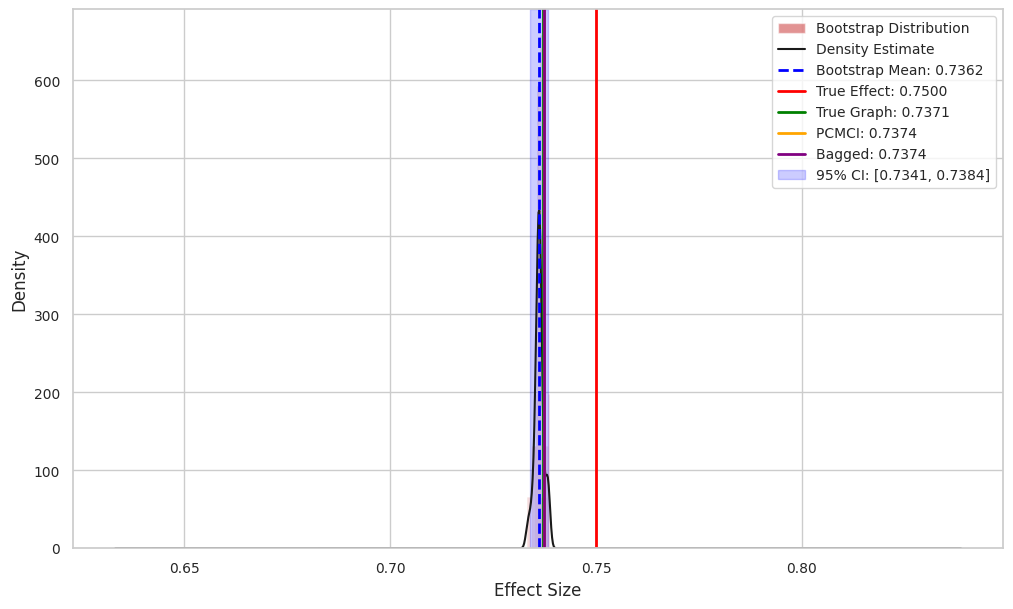

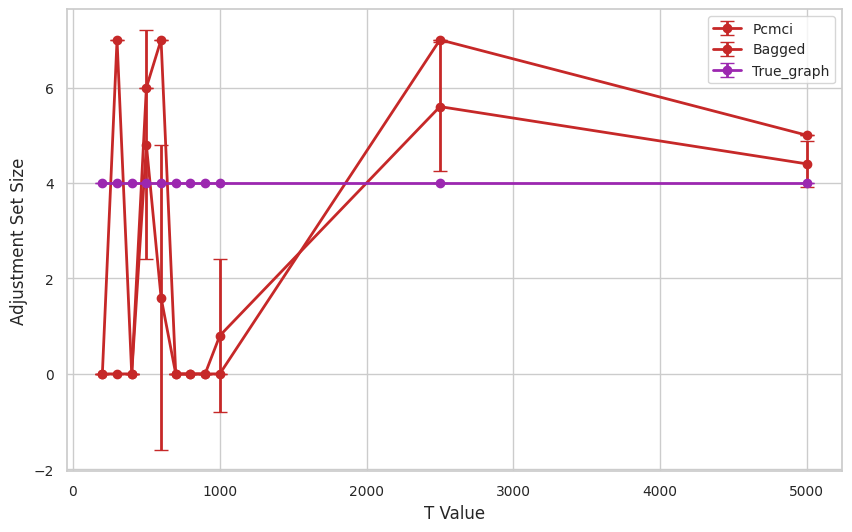

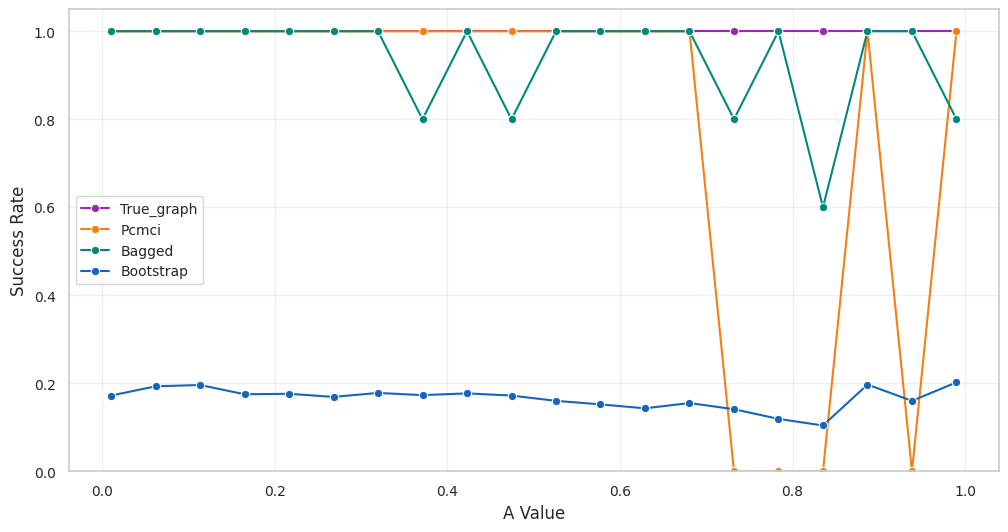

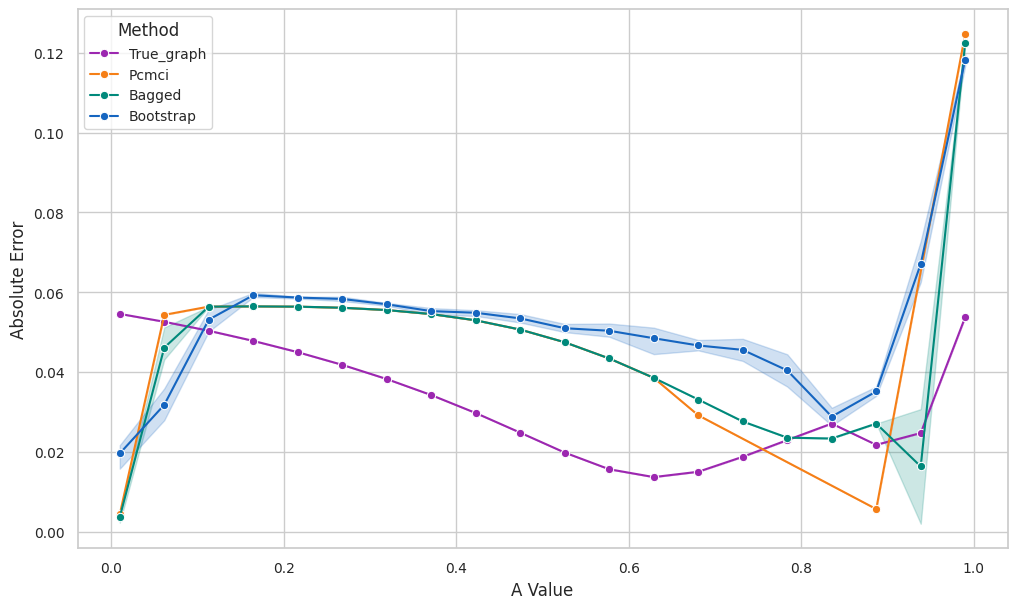

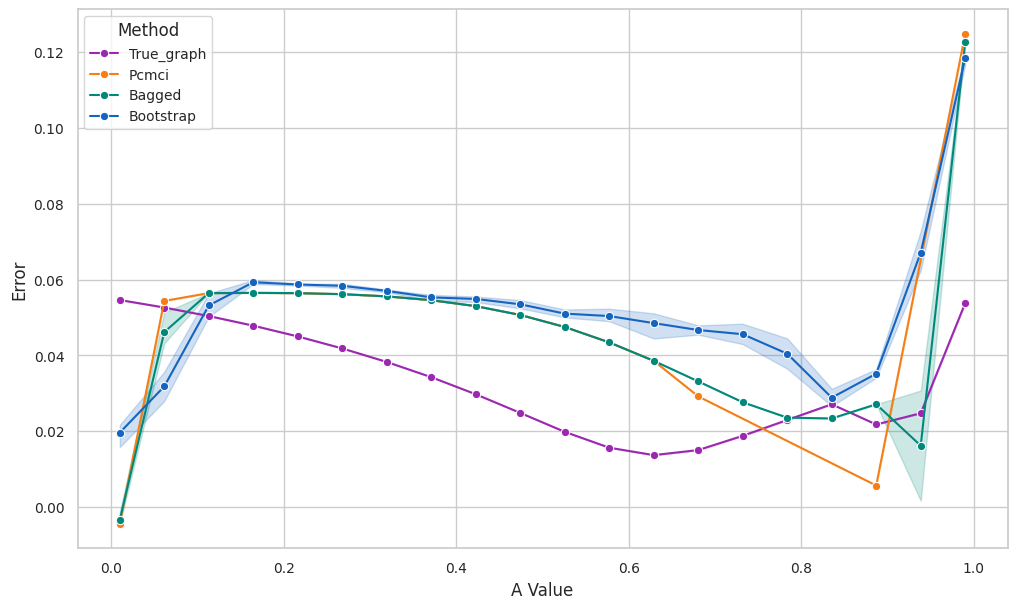

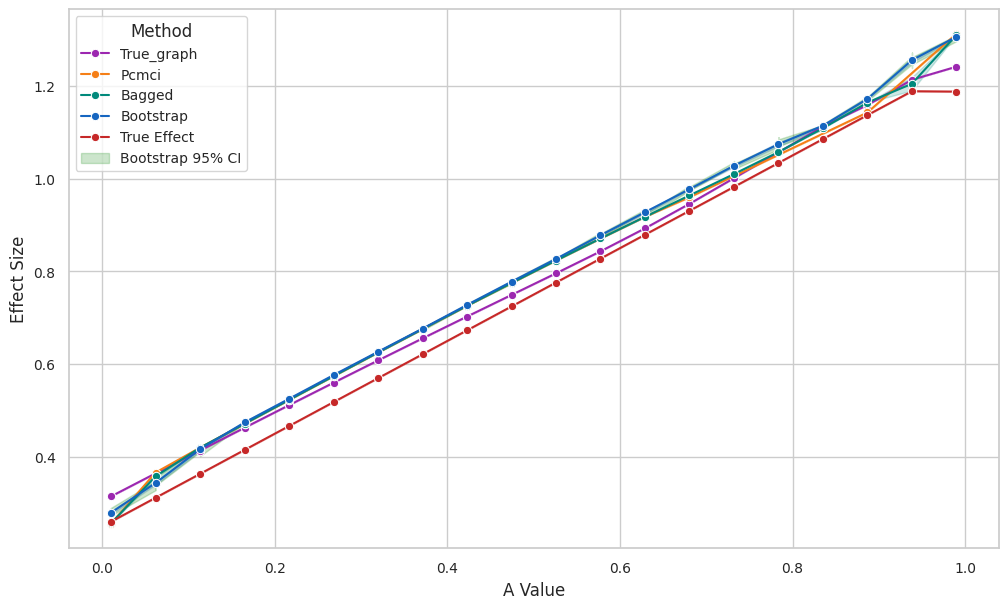

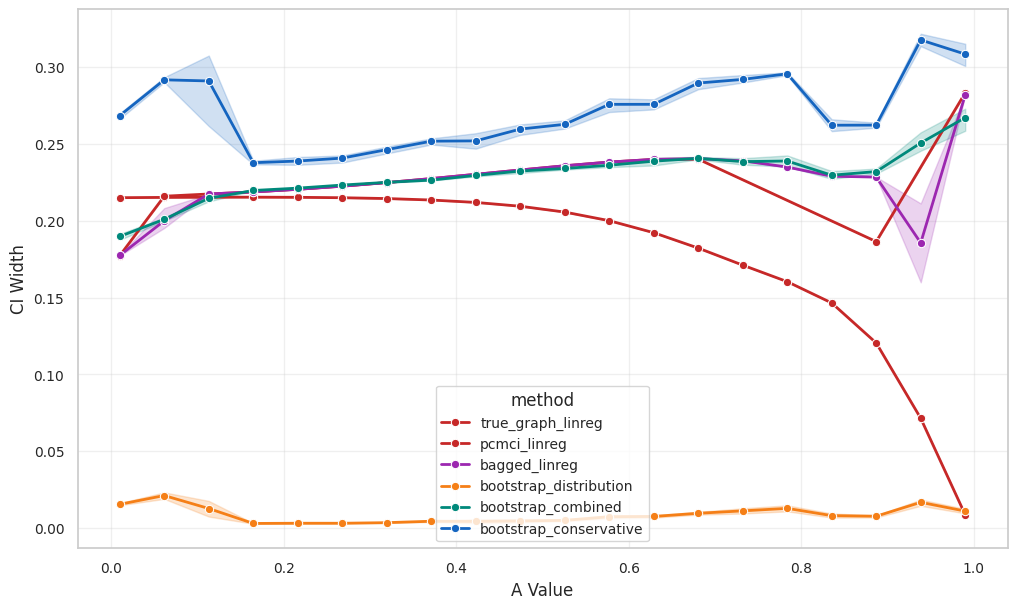

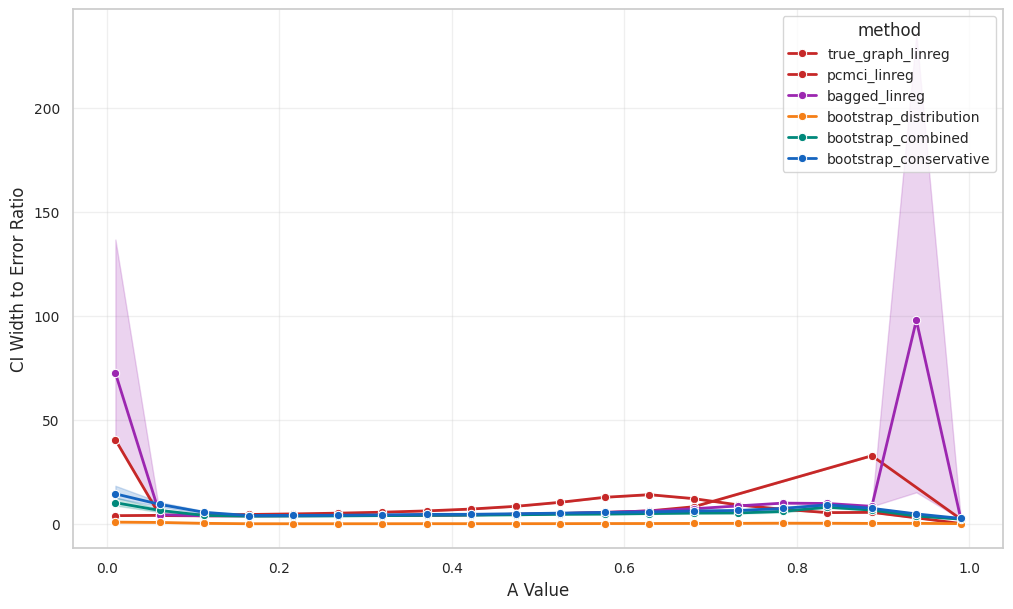

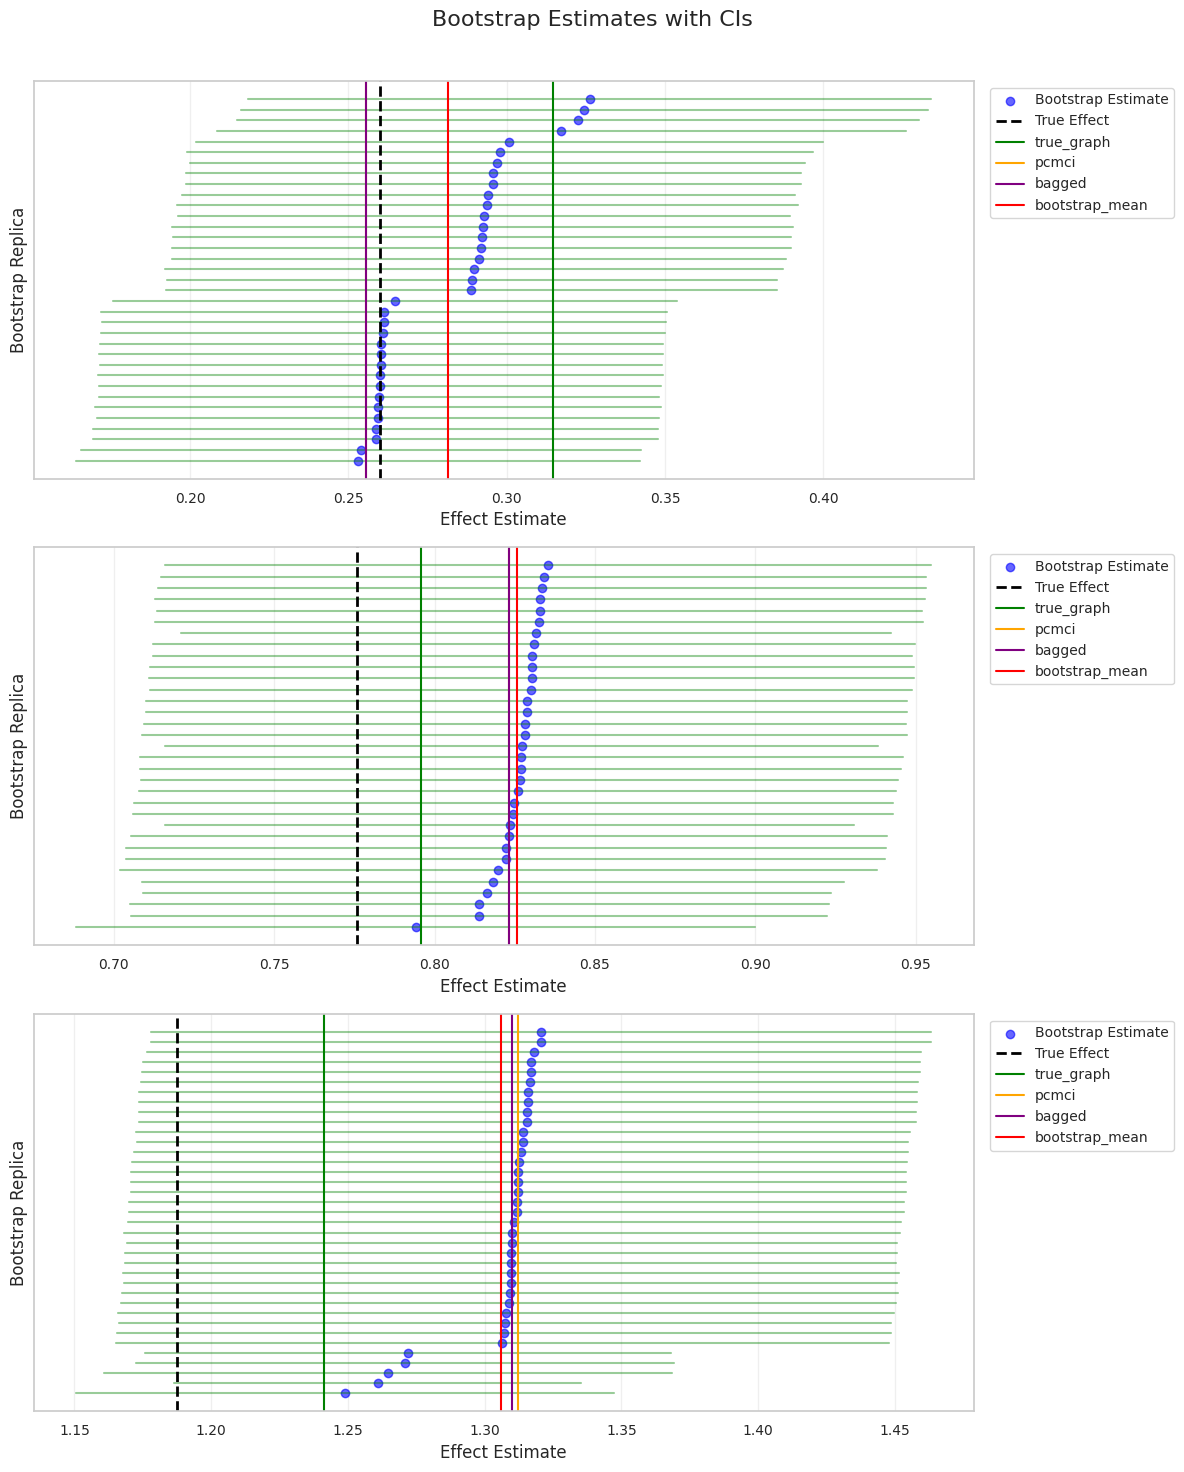

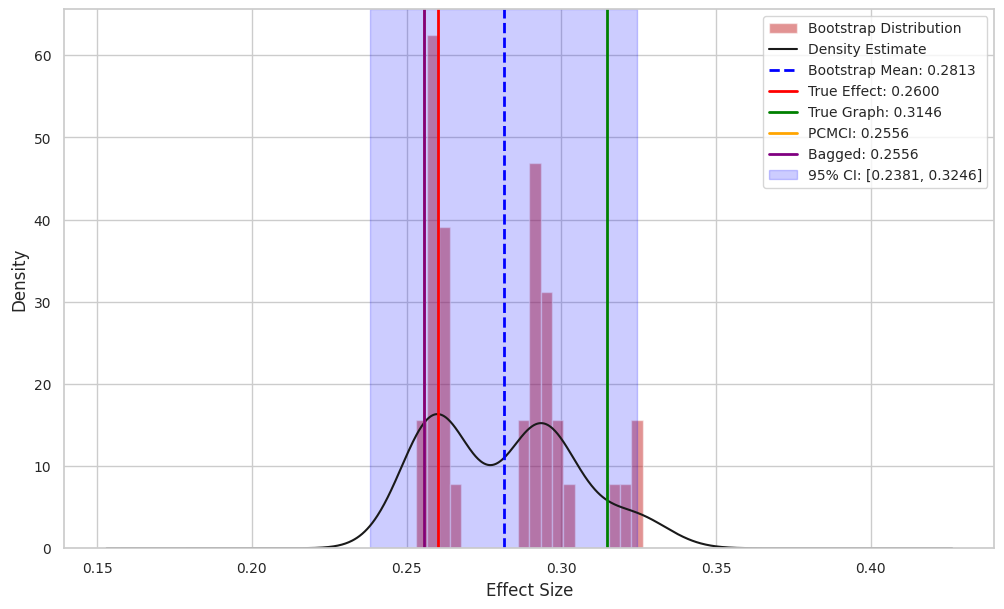

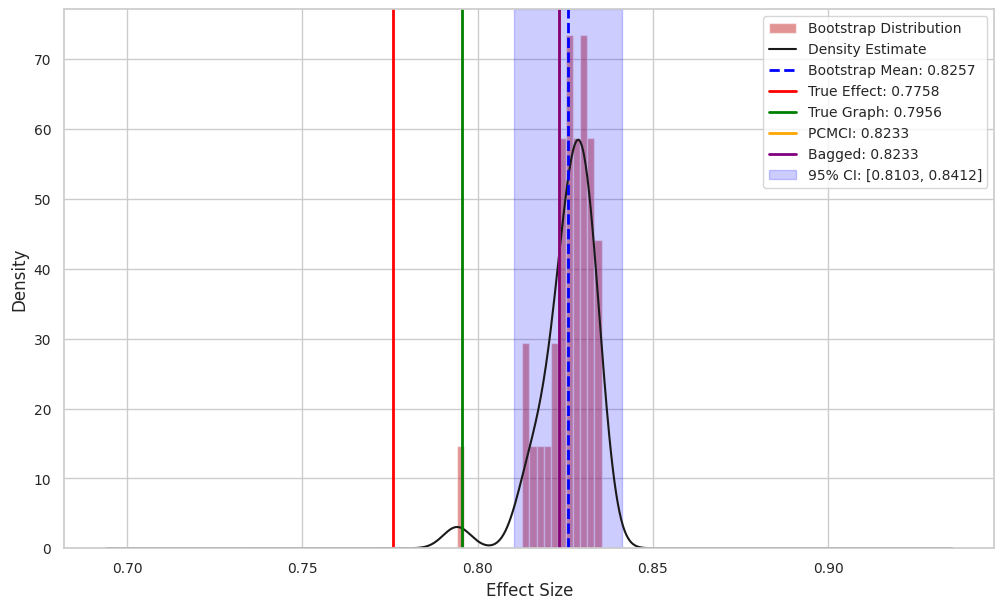

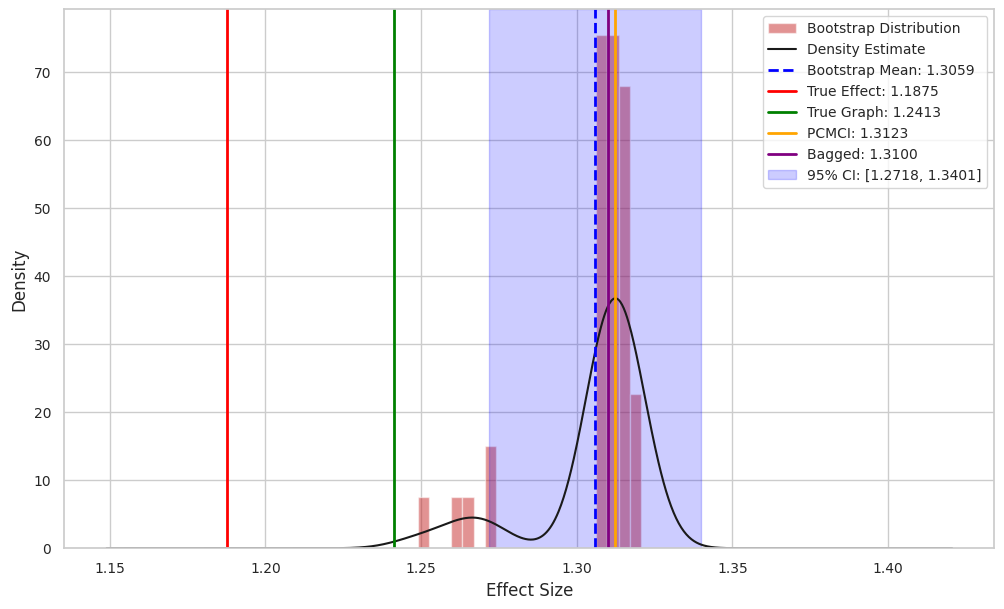

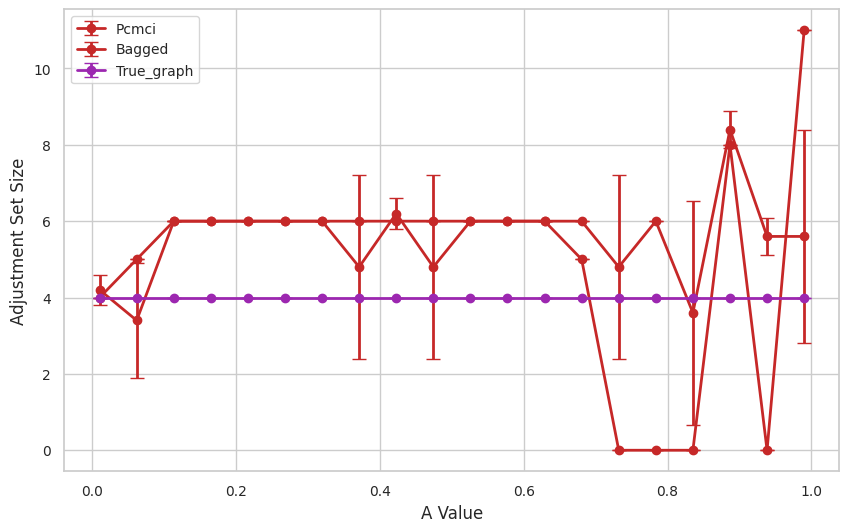

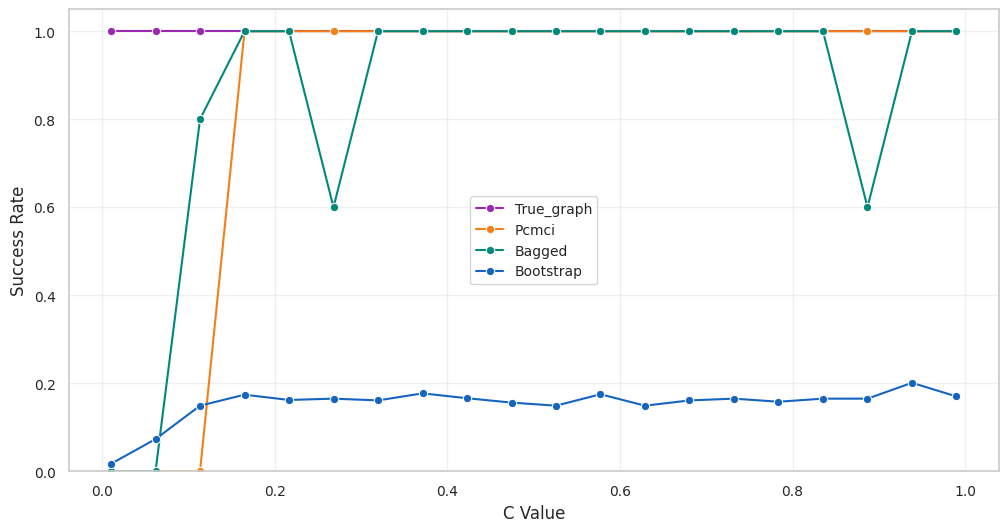

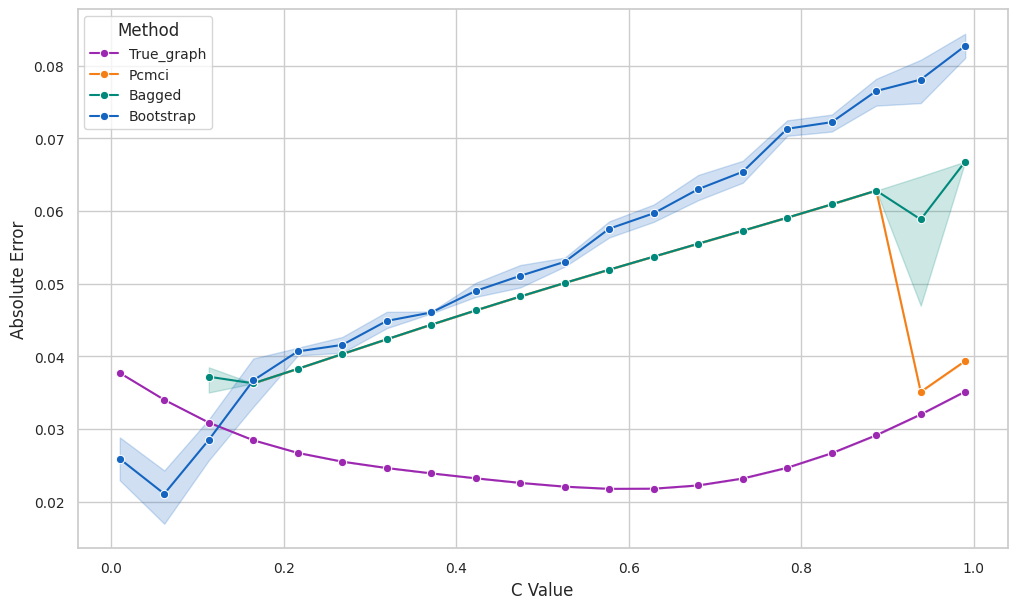

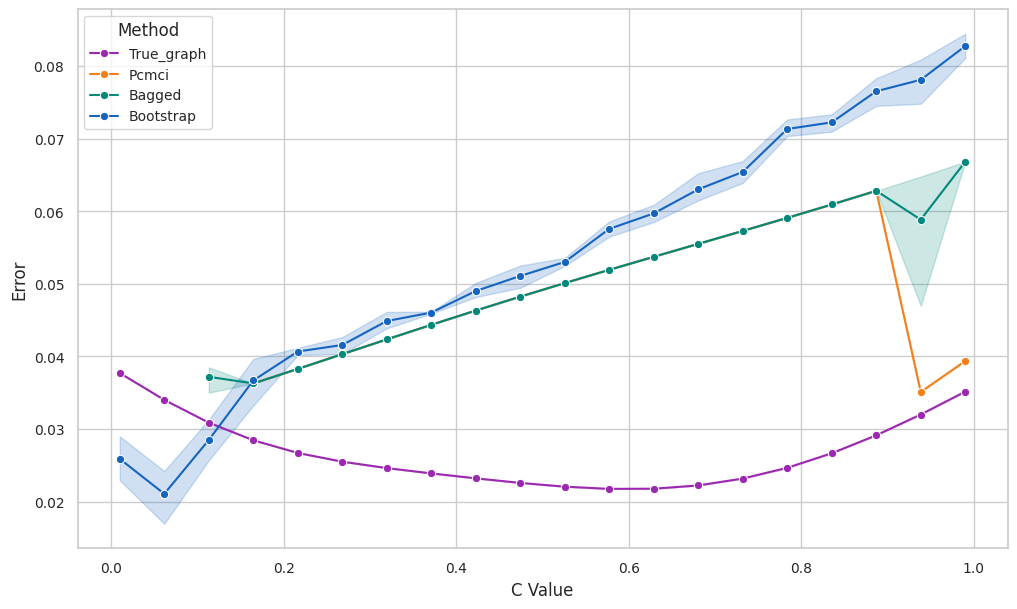

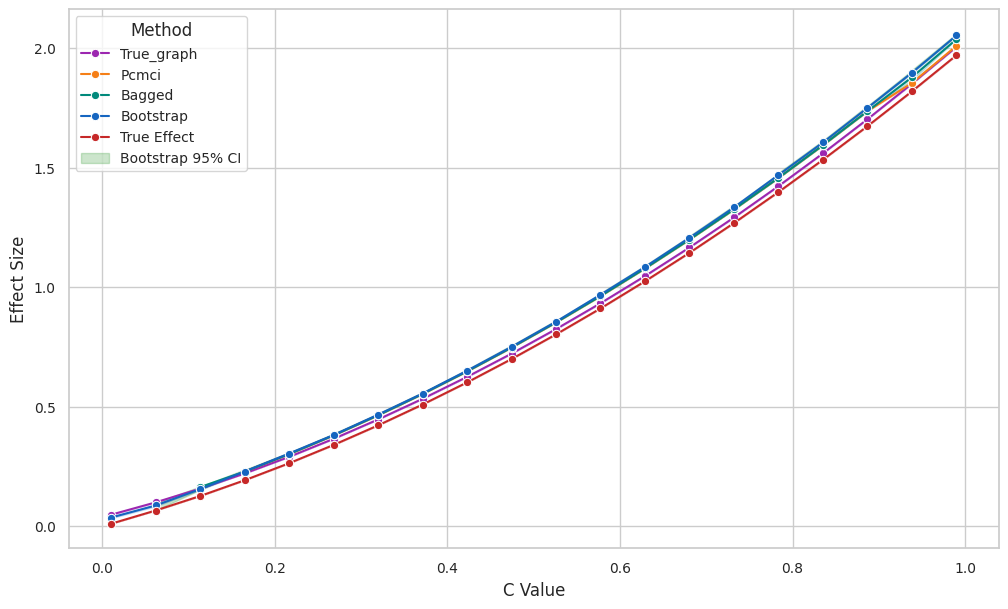

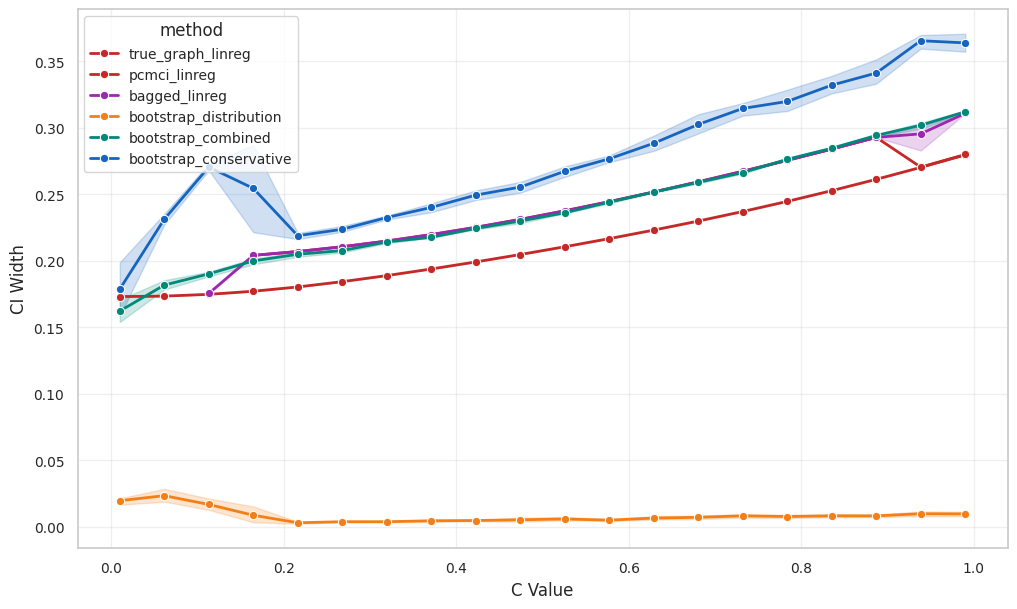

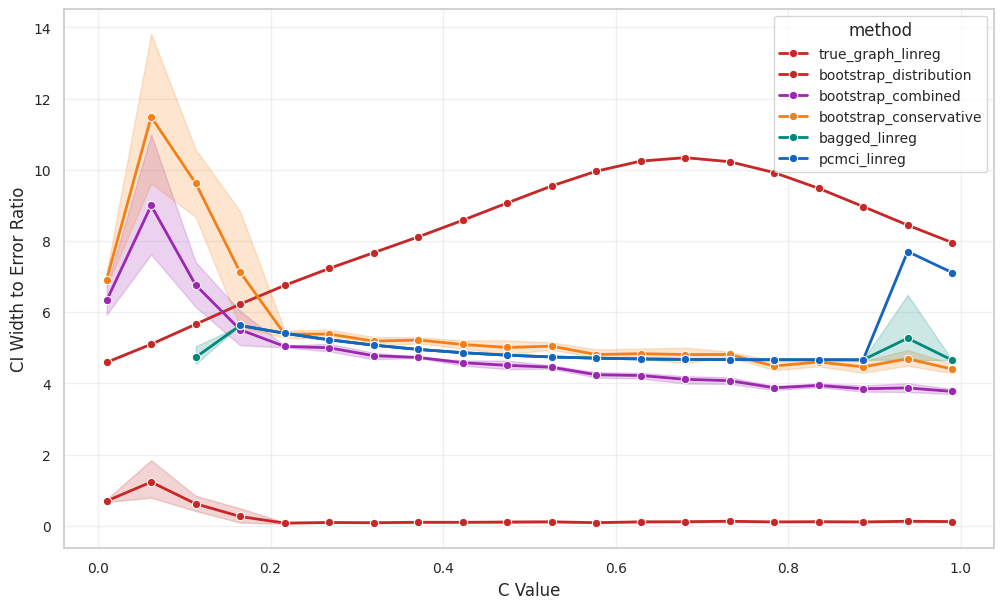

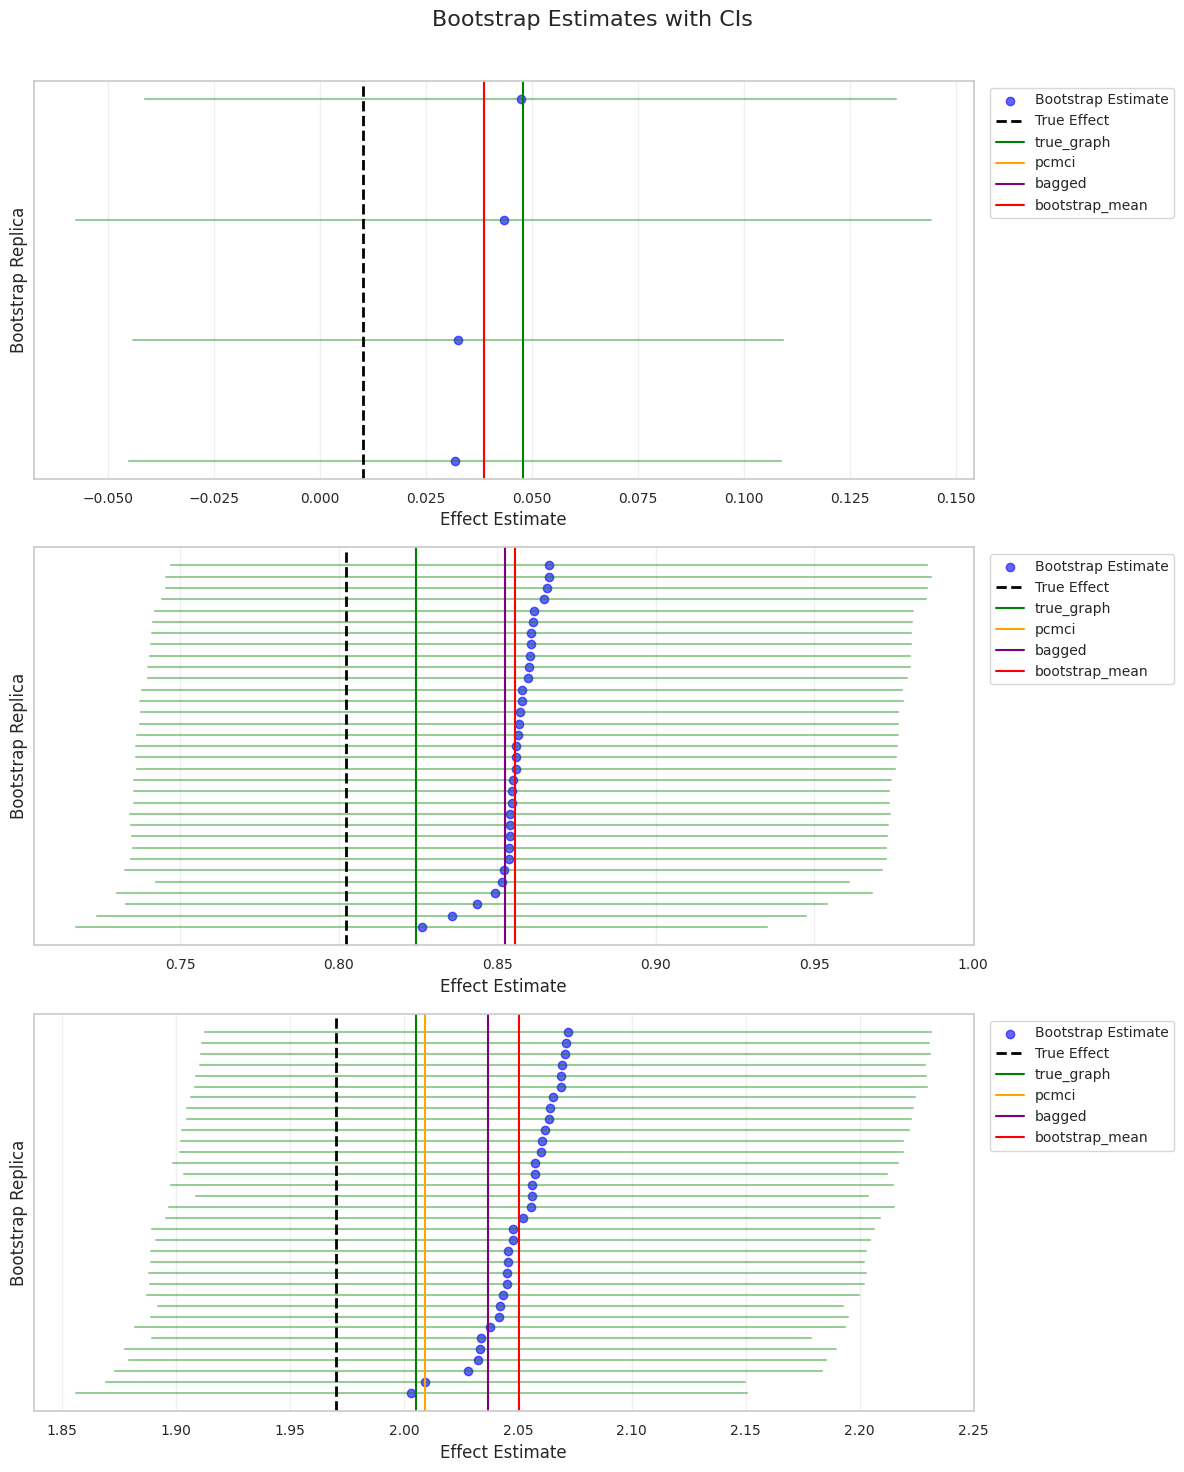

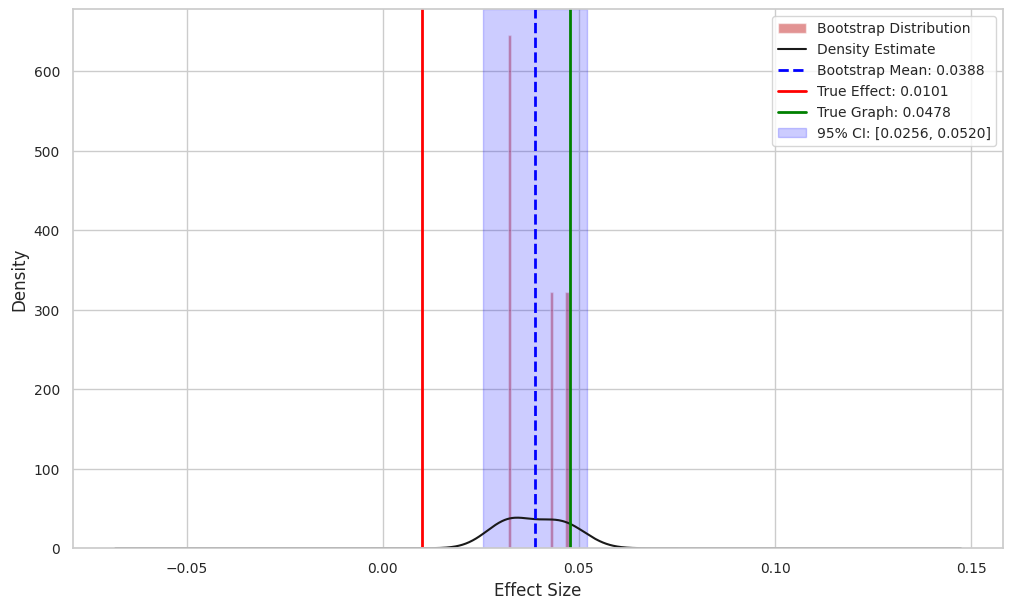

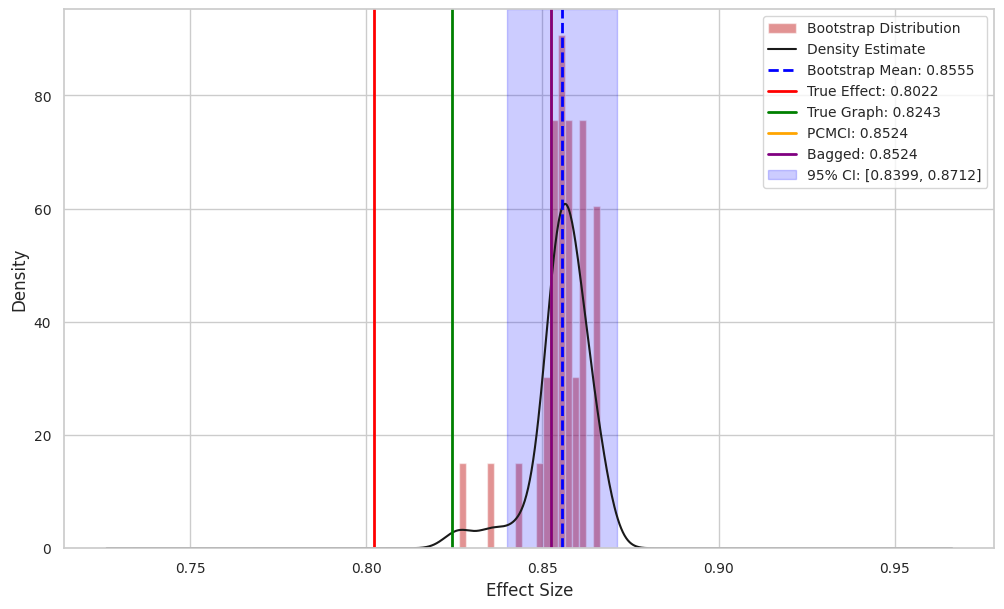

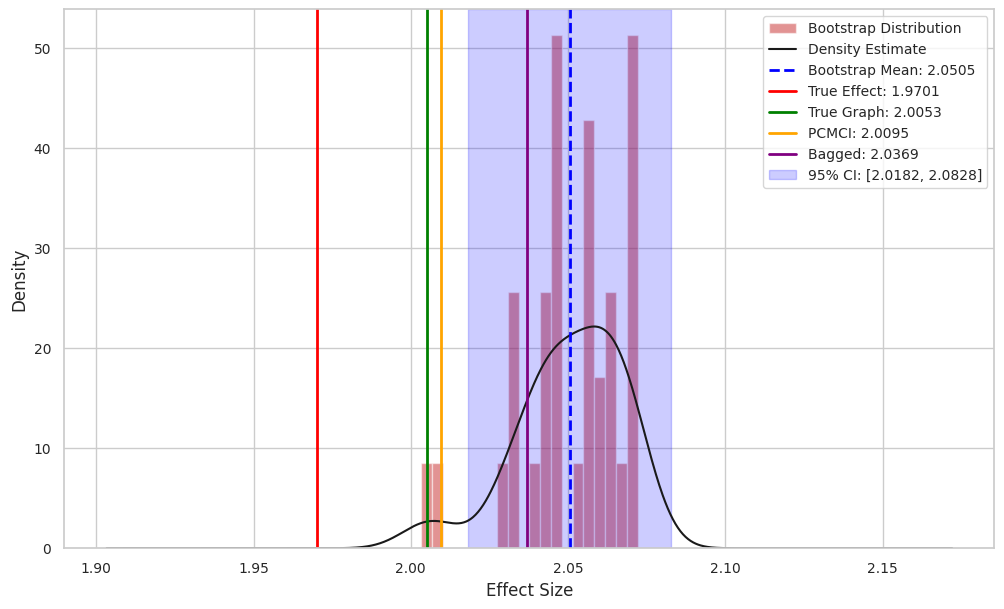

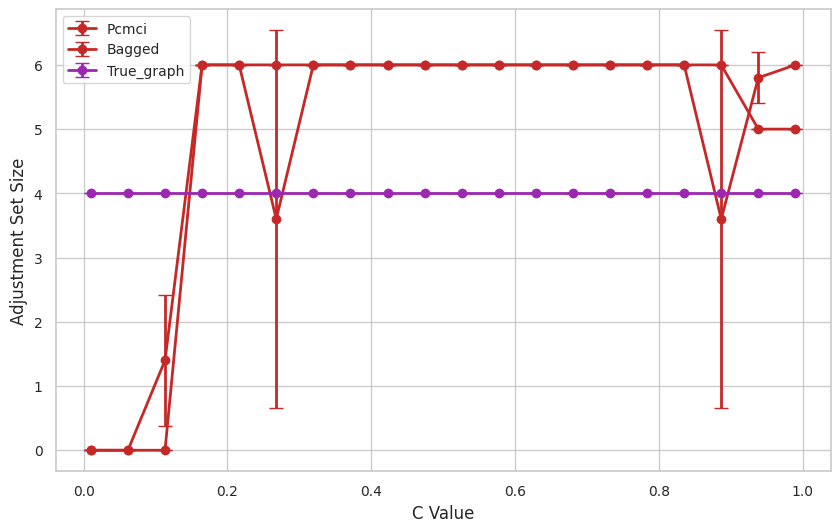

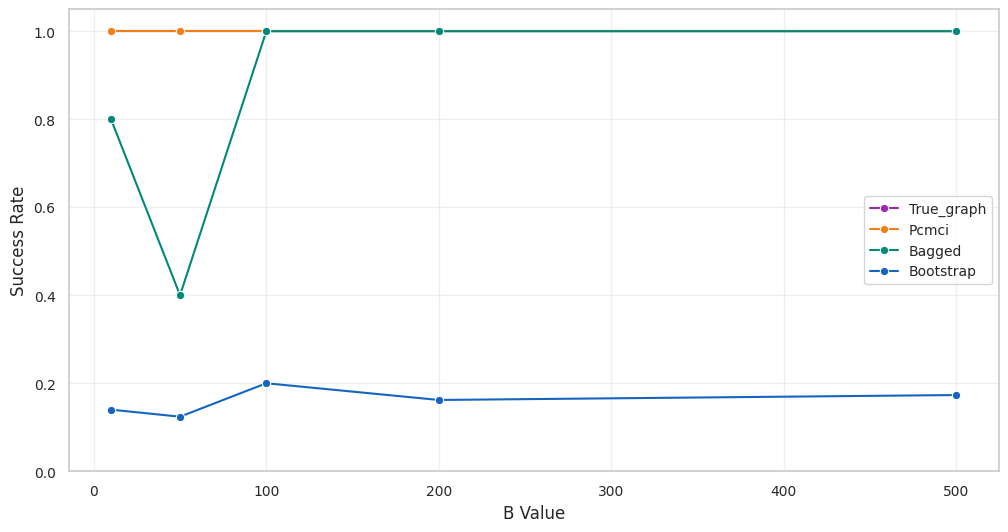

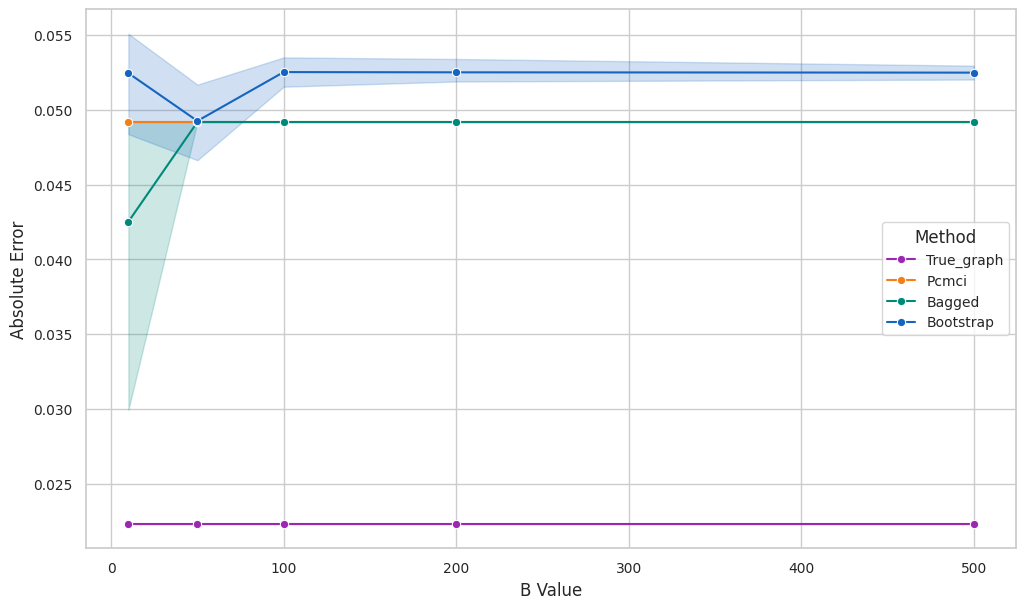

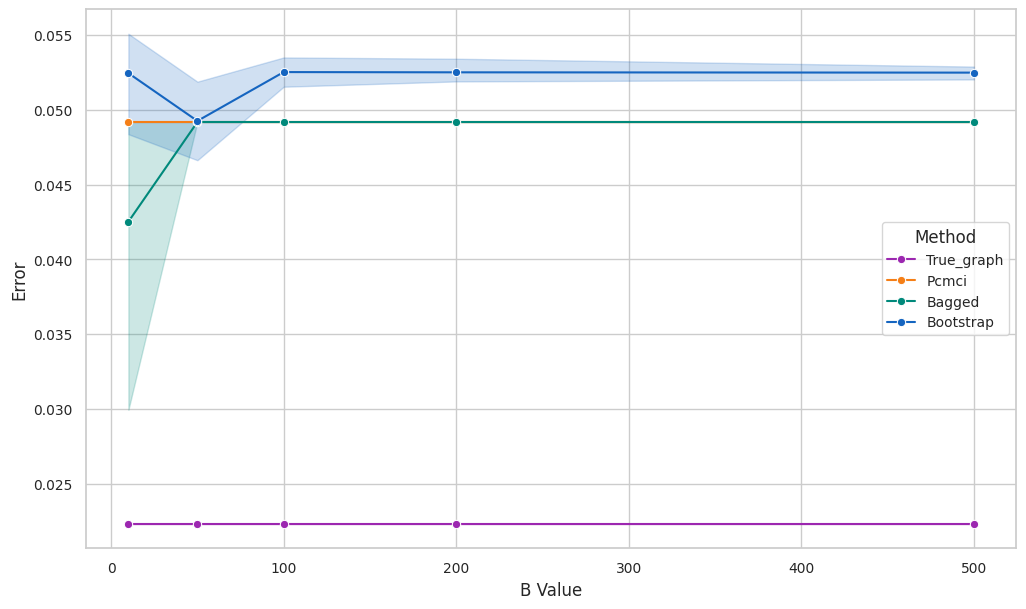

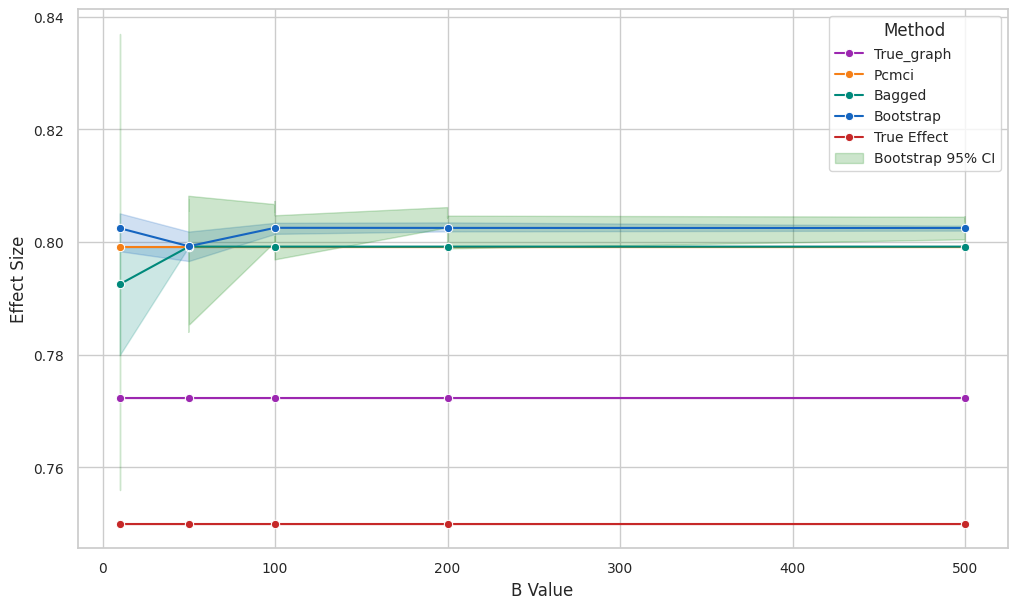

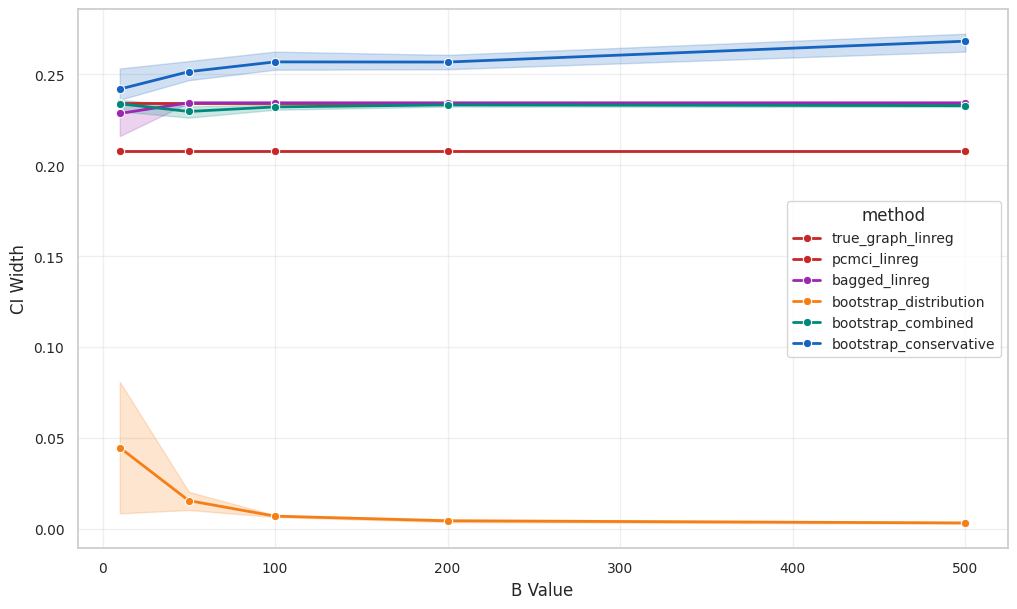

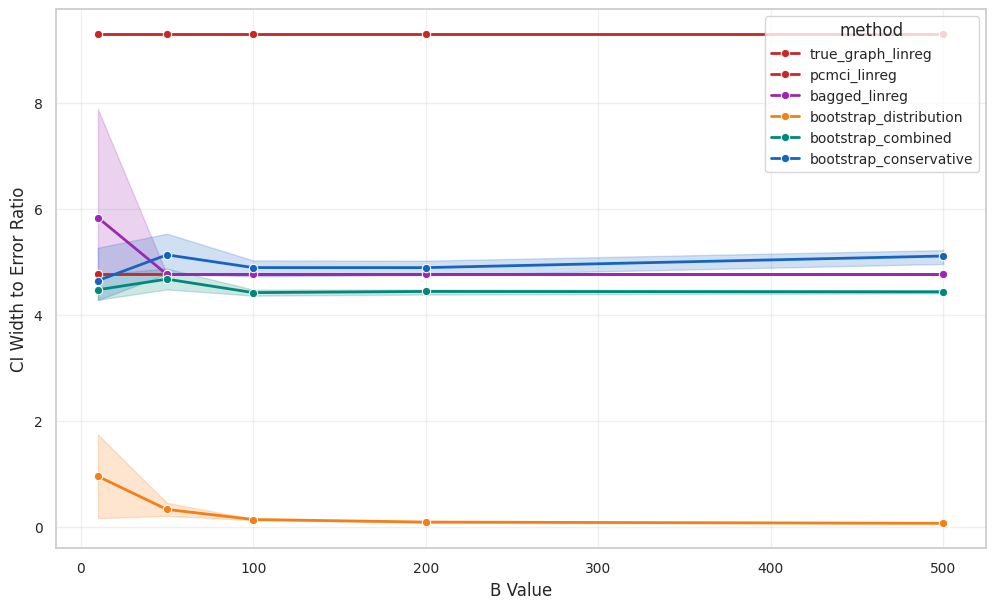

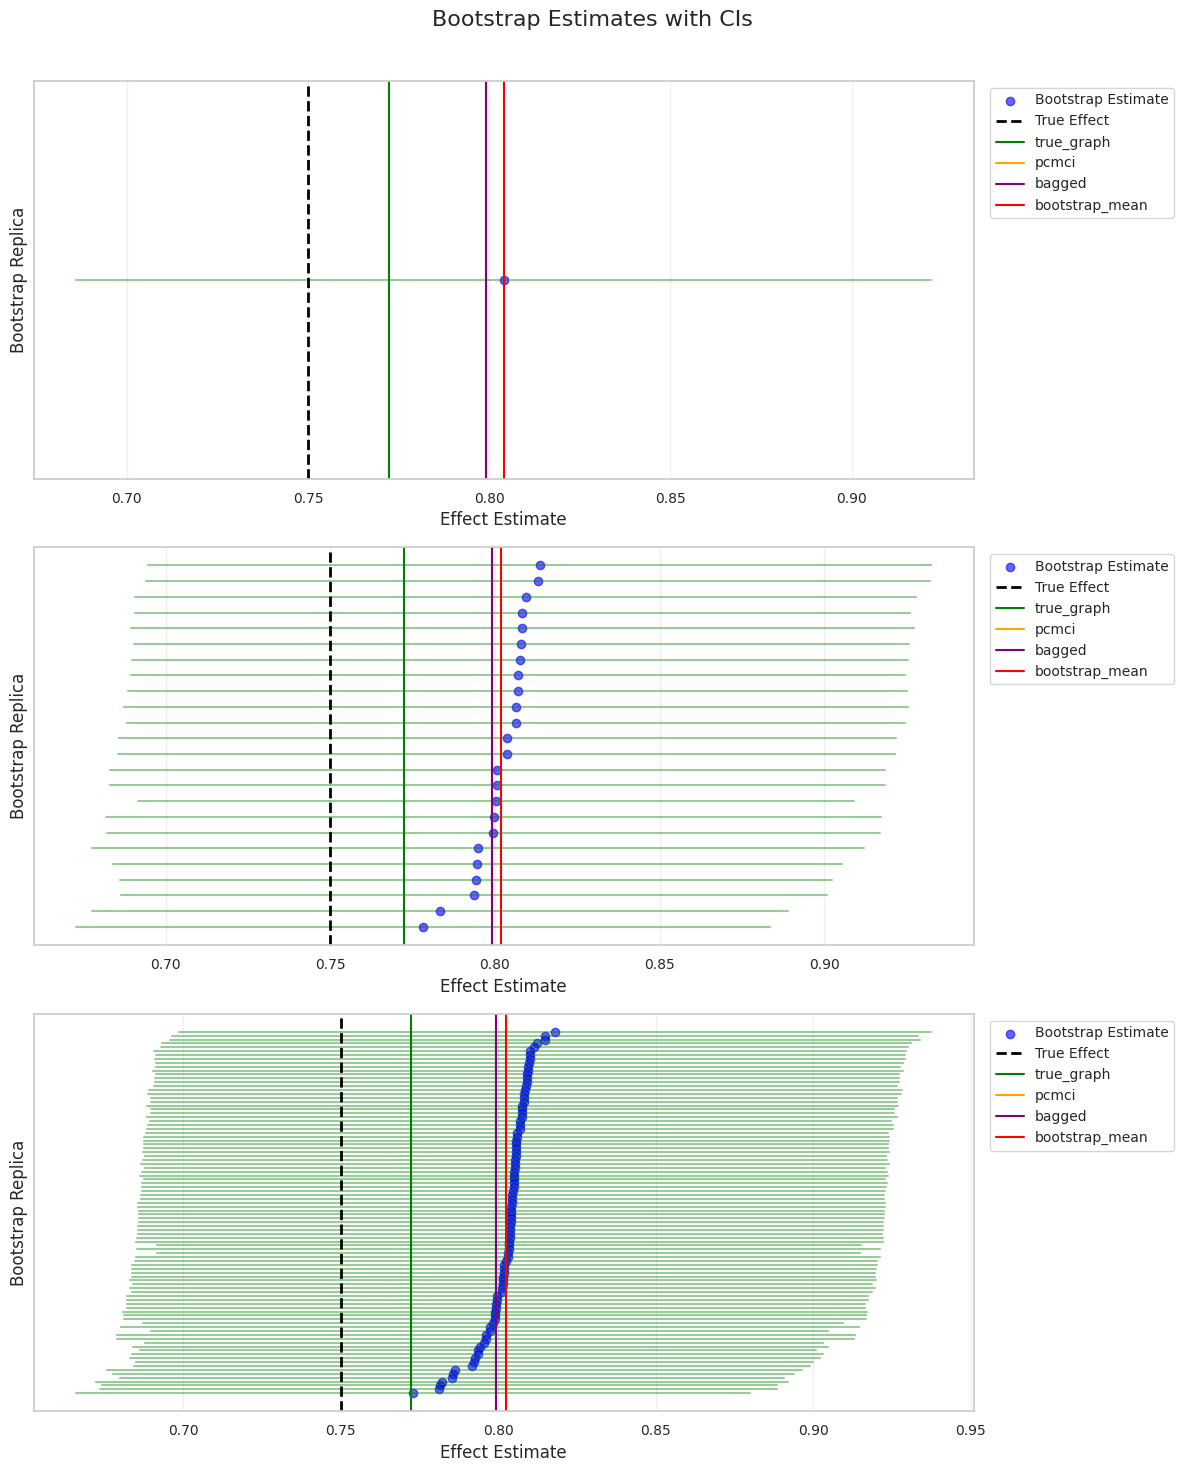

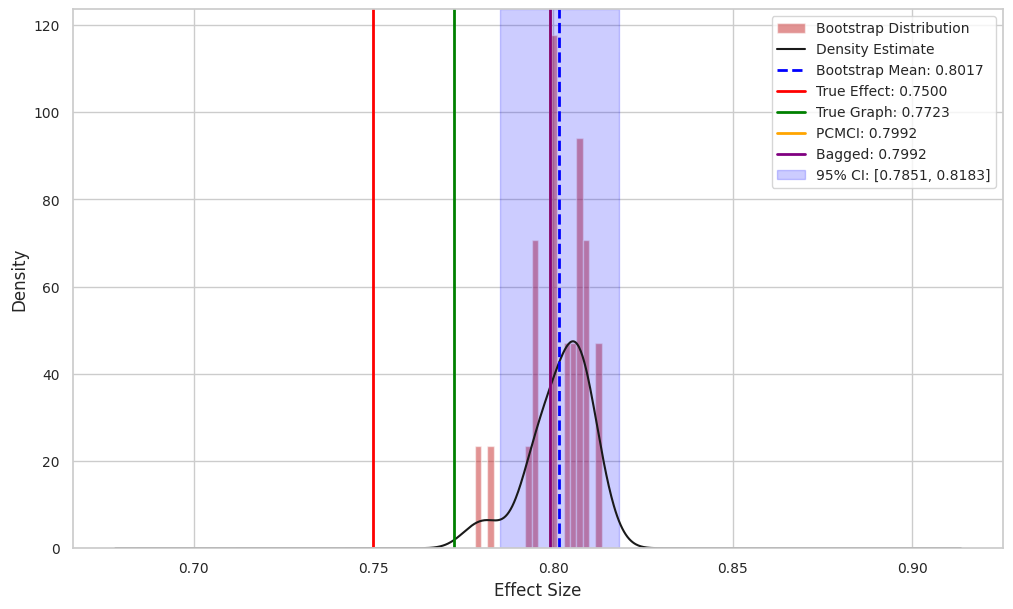

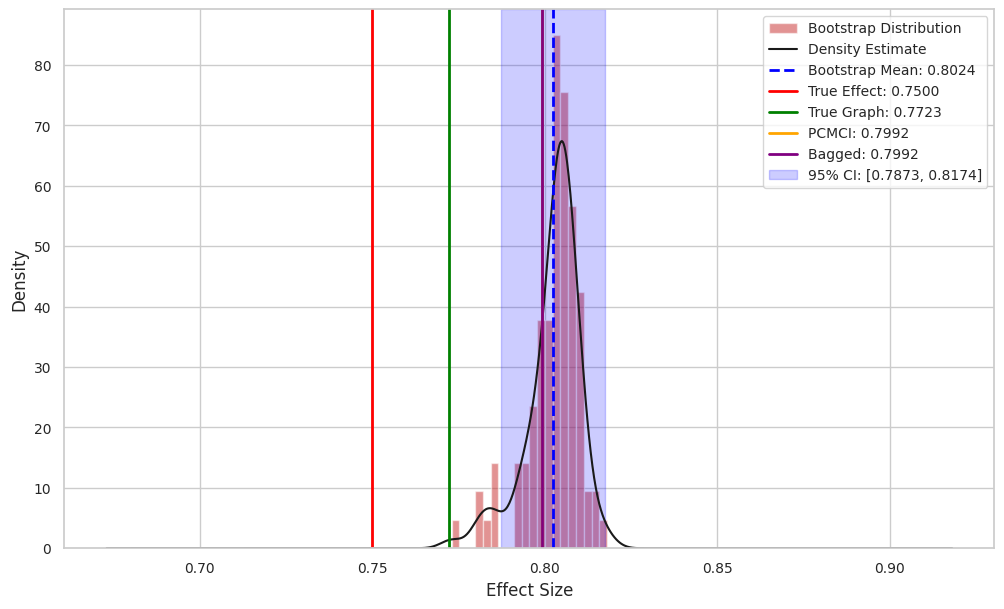

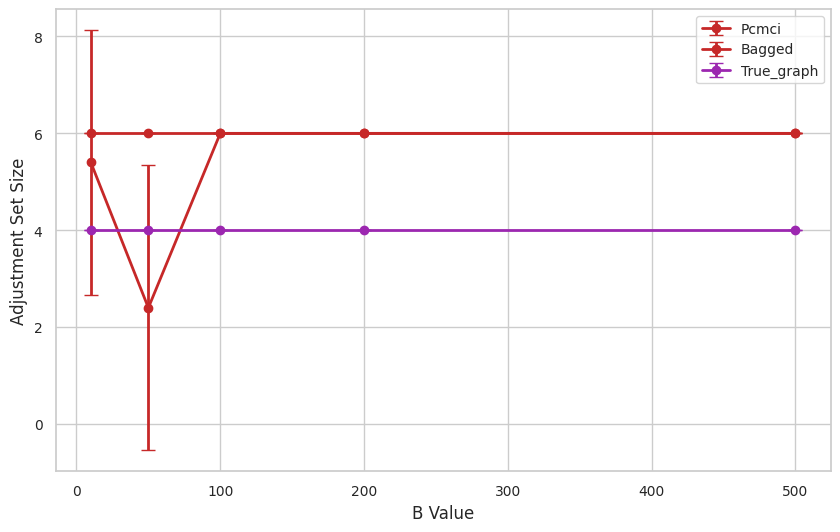

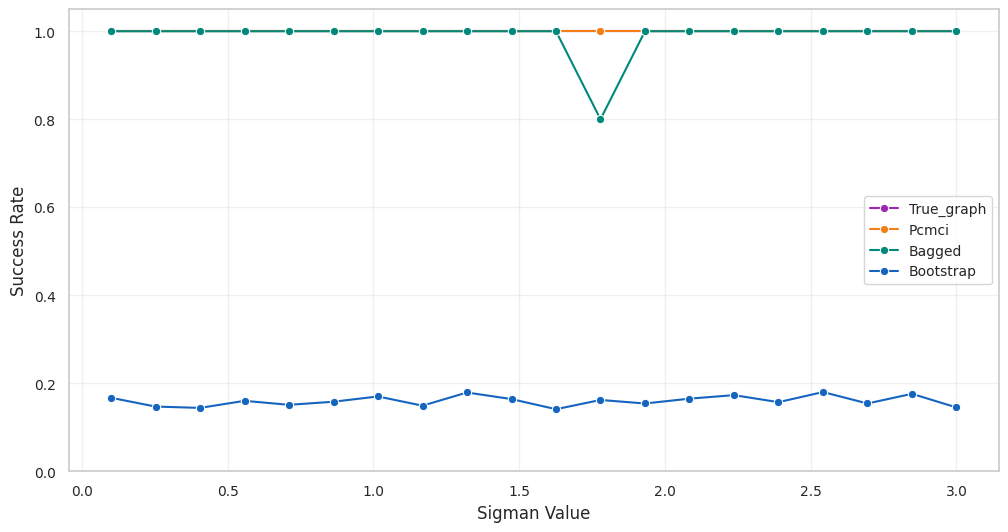

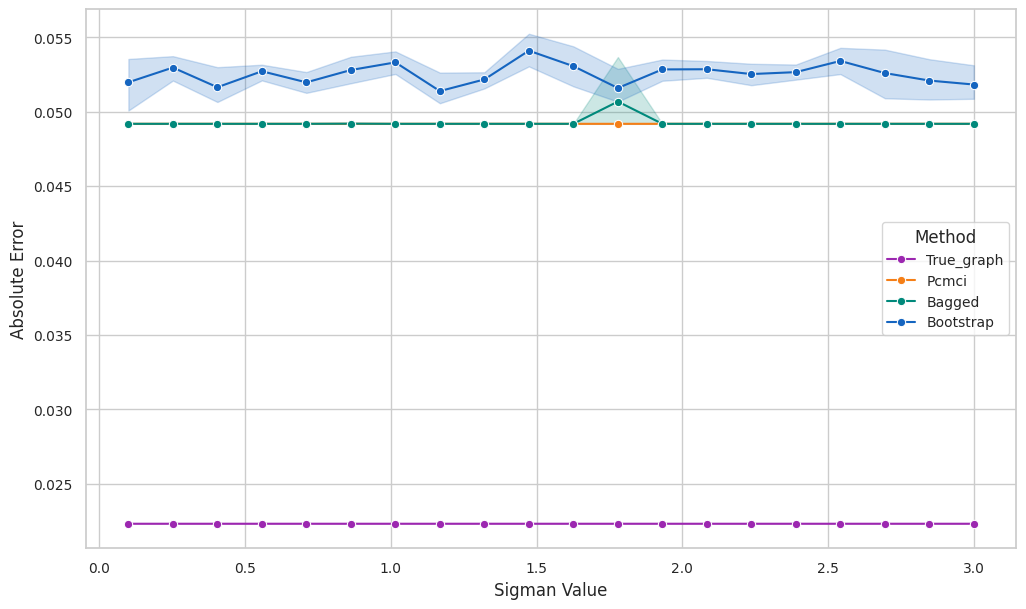

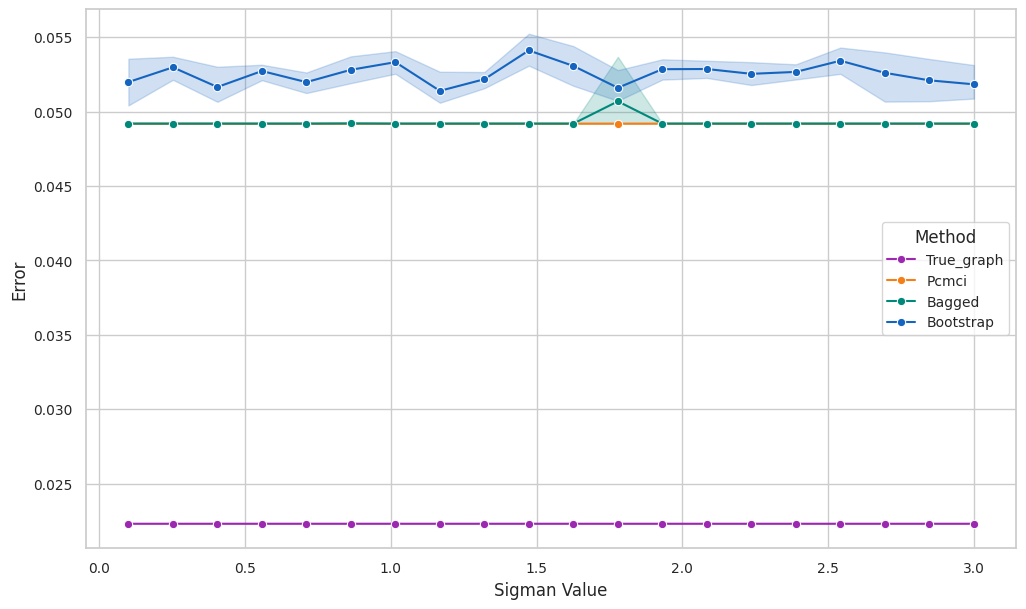

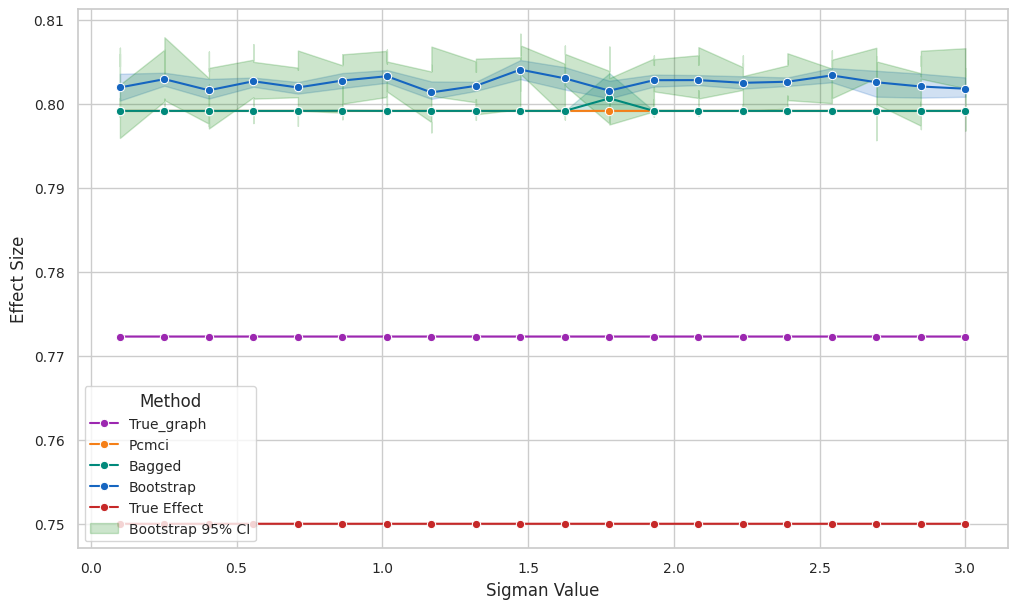

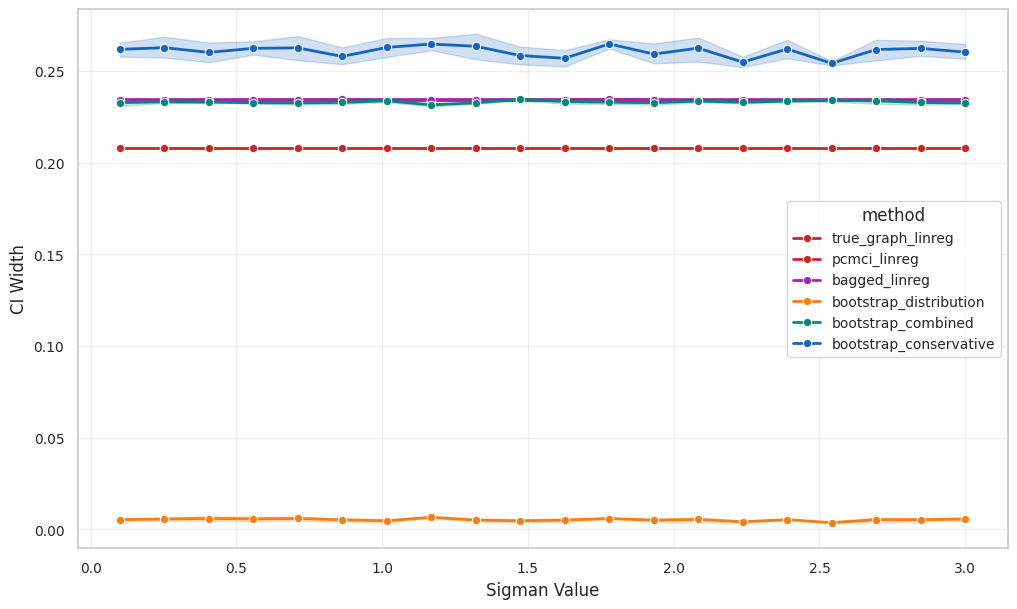

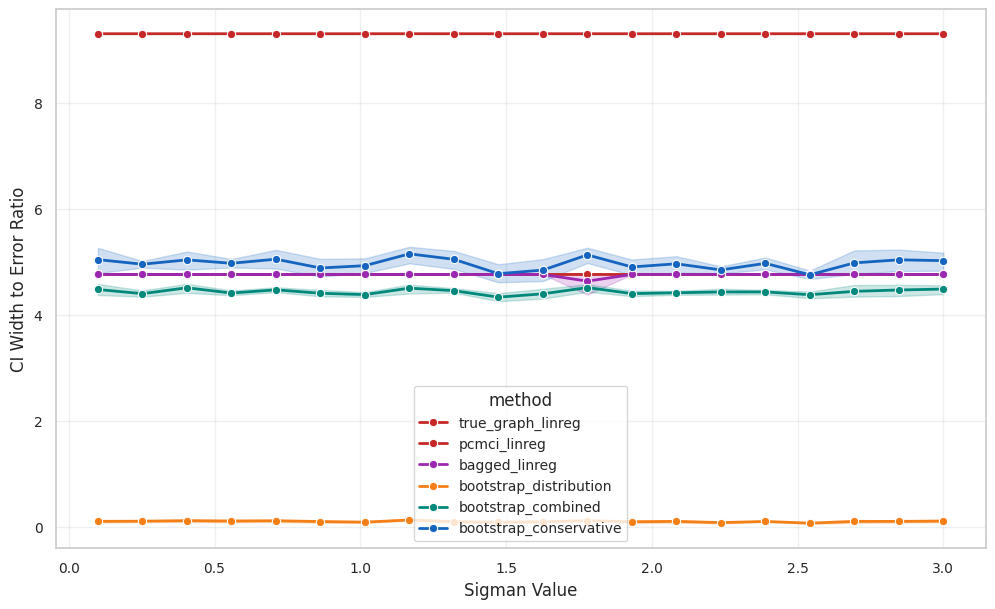

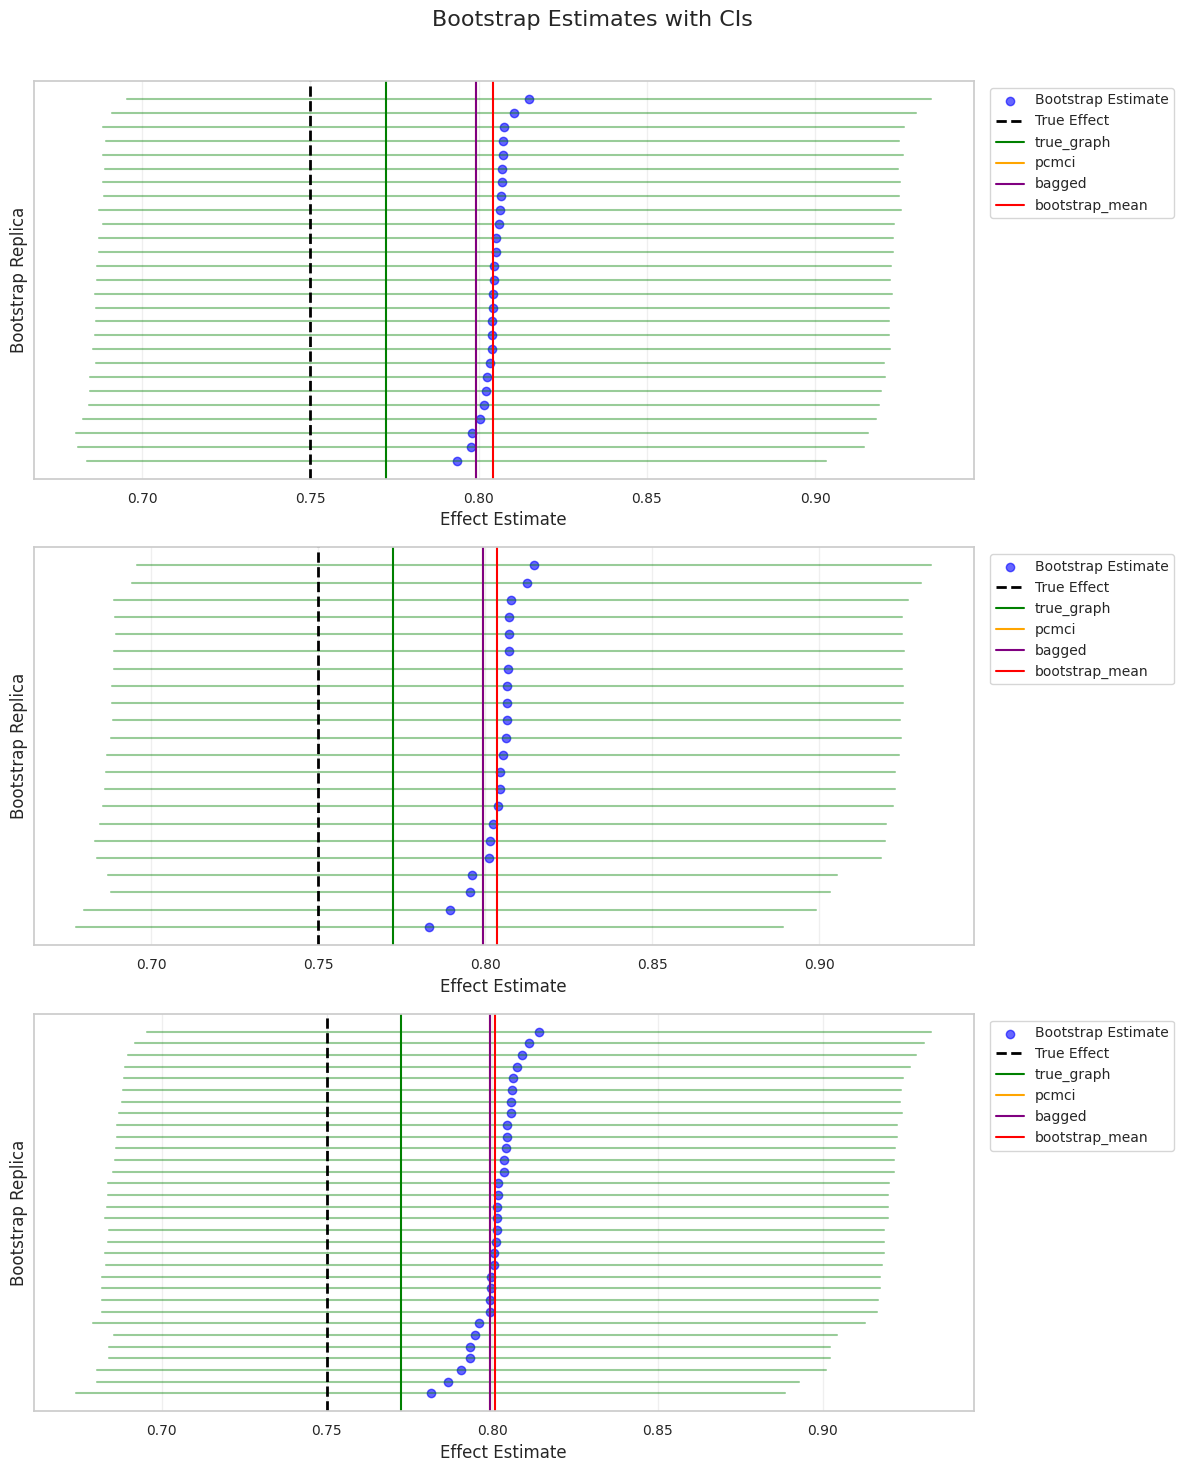

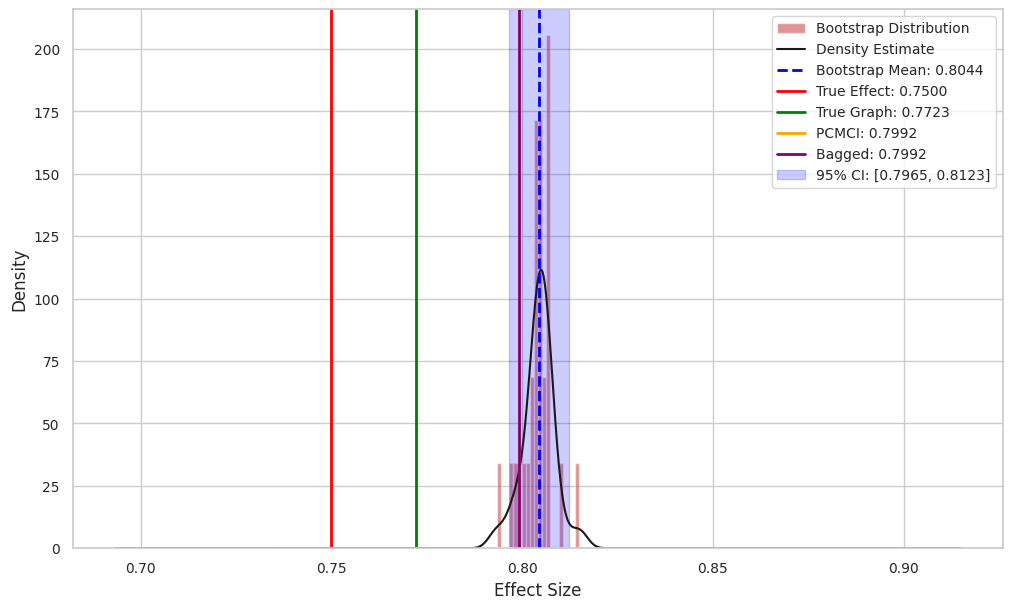

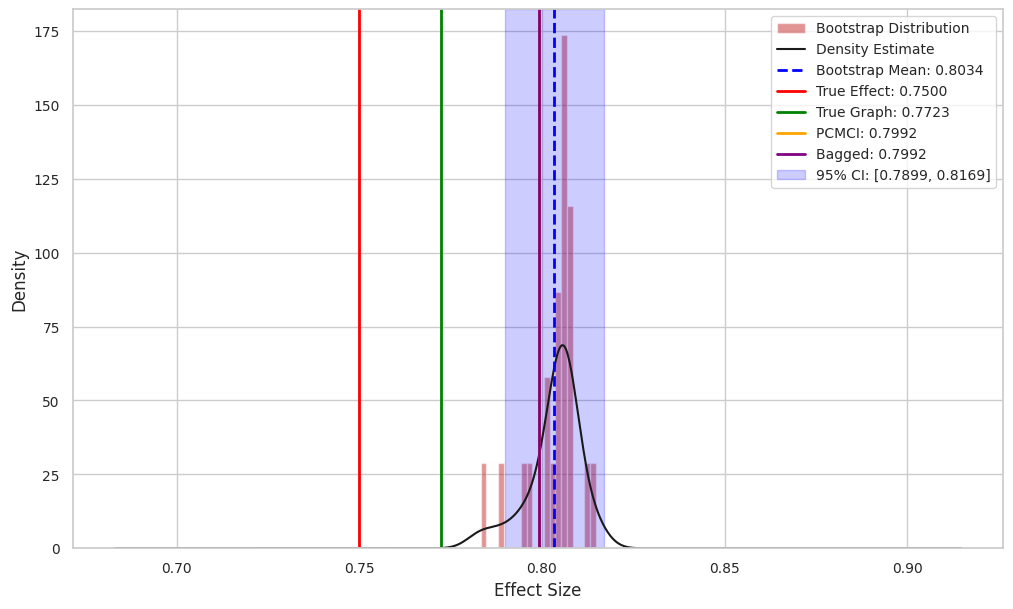

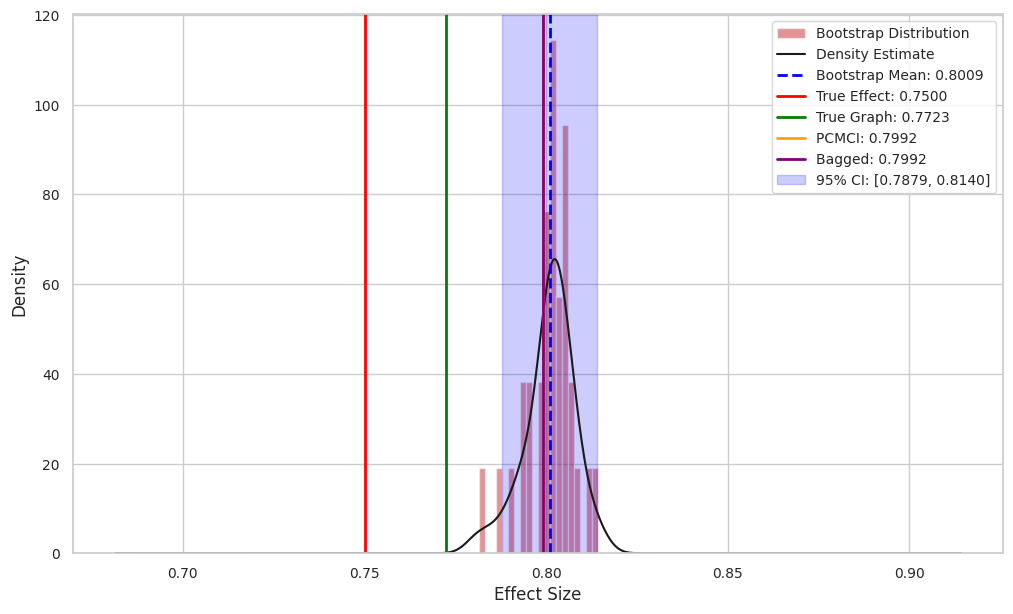

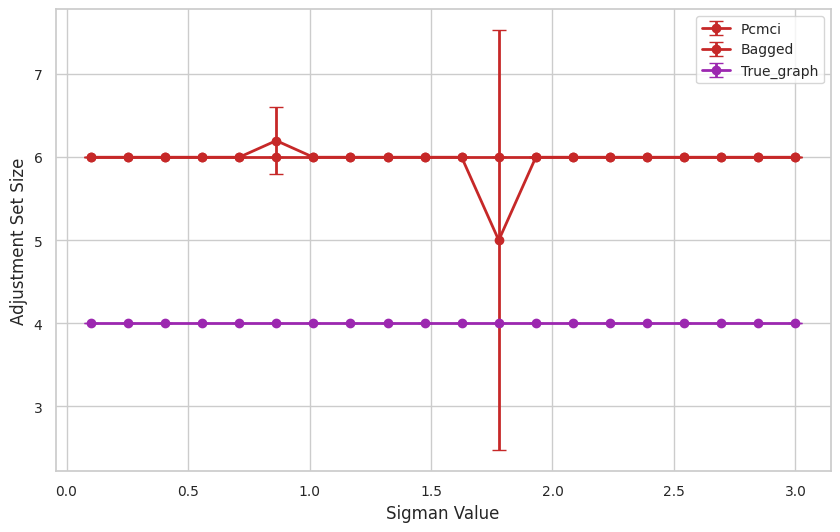

In [3]:
print("Loading study results and generating all plots...")
plot_info = generate_all_plots(main_study_folder, results_folder, studies)

## 3. Summary of Results

Display a summary of the results and the generated plots.

In [4]:
# Load the processed results for summary
all_results = pd.read_csv(os.path.join(results_folder, "all_results.csv"))

# Display summary statistics
print("\n=== Study Summary ===\n")
print(f"Total effects analyzed: {len(all_results)}")
print(f"Parameters: {all_results['param_name'].unique()}")
print(f"Effect pairs: {all_results['effect_key'].unique()}")

# Print summary of generated plots
print("\n=== Generated Plots ===\n")
for plot_type, studies_dict in plot_info.items():
    if studies_dict:  # If there are plots of this type
        print(f"\n{plot_type.capitalize()} plots:")
        for study, plots in studies_dict.items():
            if isinstance(plots, dict):
                print(f"  - {study}: {len(plots)} plots")
            else:
                print(f"  - {study}: {os.path.basename(plots)}")

print(f"\nAll results saved to: {results_folder}")


=== Study Summary ===

Total effects analyzed: 380
Parameters: ['T' 'a' 'c' 'B' 'sigmaN']
Effect pairs: ['0_-2_to_3_0']

=== Generated Plots ===


Pipeline plots:
  - T: Pipeline_timing.pdf

Ratio plots:
  - T: Ratio_timing.pdf

Replica plots:
  - n_boot: Replica_timing.pdf

Error plots:
  - T: 2 plots
  - a: 2 plots
  - c: 2 plots
  - B: 2 plots
  - sigmaN: 2 plots

Bootstrap plots:
  - T: 3 plots
  - a: 3 plots
  - c: 3 plots
  - B: 2 plots
  - sigmaN: 3 plots

Adjustment plots:
  - T: T_adjustment_sets.pdf
  - a: a_adjustment_sets.pdf
  - c: c_adjustment_sets.pdf
  - B: B_adjustment_sets.pdf
  - sigmaN: sigmaN_adjustment_sets.pdf

Error_vs_ci_width plots:
  - overall: overall_error_vs_ci_width.pdf

Estimation_success plots:
  - overall: overall_estimation_success.pdf
  - T: T_estimation_success.pdf
  - a: a_estimation_success.pdf
  - c: c_estimation_success.pdf
  - B: B_estimation_success.pdf
  - sigmaN: sigmaN_estimation_success.pdf

All results saved to: analysis_results_2025-04-

## 4. Error Metrics

Calculate and display summary error metrics for each method and parameter.

In [5]:
# Group by parameter name and value
error_metrics = []
for param_name in all_results['param_name'].unique():
    for param_value in sorted(all_results[all_results['param_name'] == param_name]['param_value'].unique()):
        subset = all_results[(all_results['param_name'] == param_name) & 
                             (all_results['param_value'] == param_value)]
        
        # Calculate metrics for each method
        metrics = {'param_name': param_name, 'param_value': param_value}
        
        for method in ['pcmci', 'bagged', 'bootstrap']:
            error_col = f'{method}_abs_error'
            bias_col = f'{method}_error'
            
            if error_col in subset.columns:
                errors = subset[error_col].dropna()
                if len(errors) > 0:
                    metrics[f'{method}_mae'] = errors.mean()
                    metrics[f'{method}_rmse'] = np.sqrt((errors**2).mean())
            
            if bias_col in subset.columns:
                biases = subset[bias_col].dropna()
                if len(biases) > 0:
                    metrics[f'{method}_bias'] = biases.mean()
        
        # Add CI coverage if available
        if 'ci_covers_true' in subset.columns:
            coverage = subset['ci_covers_true'].dropna()
            if len(coverage) > 0:
                metrics['bootstrap_ci_coverage'] = coverage.mean()
        
        error_metrics.append(metrics)

# Convert to DataFrame and save
error_df = pd.DataFrame(error_metrics)
error_df.to_csv(os.path.join(results_folder, "error_metrics_summary.csv"), index=False)

# Display error metrics
print("\n=== Error Metrics Summary ===\n")
print(error_df)

# Create a simplified metrics table for each parameter
for param_name in error_df['param_name'].unique():
    param_df = error_df[error_df['param_name'] == param_name].copy()
    param_df = param_df.sort_values('param_value')
    
    # Select most important columns
    cols_to_display = ['param_value', 'pcmci_mae', 'bagged_mae', 'bootstrap_mae']
    if 'bootstrap_ci_coverage' in param_df.columns:
        cols_to_display.append('bootstrap_ci_coverage')
    
    # Display and save
    print(f"\n{param_name.capitalize()} study metrics:")
    print(param_df[cols_to_display])
    
    # Save to CSV
    param_df.to_csv(os.path.join(results_folder, f"{param_name}_metrics.csv"), index=False)


=== Error Metrics Summary ===

   param_name  param_value  bootstrap_mae  bootstrap_rmse  bootstrap_bias  \
0           T   200.000000       0.074036        0.074183        0.074036   
1           T   300.000000       0.159464        0.159468        0.159464   
2           T   400.000000       0.074671        0.074723        0.074671   
3           T   500.000000       0.050897        0.050920        0.050897   
4           T   600.000000       0.019662        0.020101        0.019662   
..        ...          ...            ...             ...             ...   
71     sigmaN     2.389474       0.052662        0.052665        0.052662   
72     sigmaN     2.542105       0.053413        0.053423        0.053413   
73     sigmaN     2.694737       0.052599        0.052631        0.052599   
74     sigmaN     2.847368       0.052095        0.052122        0.052095   
75     sigmaN     3.000000       0.051828        0.051845        0.051828   

    bagged_mae  bagged_rmse  bagged_bias  p

## 5. Display Key Plots

Display some of the generated plots directly in the notebook.

In [6]:
# Helper function to display plots
def display_plot(filepath, figsize=(10, 6)):
    """Display a plot from file in the notebook"""
    if not os.path.exists(filepath):
        print(f"Plot not found: {filepath}")
        return
    
    plt.figure(figsize=figsize)
    img = plt.imread(filepath)
    plt.imshow(img)
    plt.axis('off')
    plt.title(os.path.basename(filepath))
    plt.show()

# Display a selection of plots
print("\n=== Sample Plots ===\n")

# Display error plots for each parameter
for param_name in error_df['param_name'].unique():
    if param_name in plot_info['error'] and 'abs' in plot_info['error'][param_name]:
        print(f"\n{param_name.capitalize()} absolute error:")
        display_plot(plot_info['error'][param_name]['abs'])
    
    # Display a bootstrap distribution plot if available
    if param_name in plot_info['bootstrap'] and plot_info['bootstrap'][param_name]:
        # Get one bootstrap plot (the first one)
        bs_plot = next(iter(plot_info['bootstrap'][param_name].values()))
        print(f"\n{param_name.capitalize()} bootstrap distribution:")
        display_plot(bs_plot)
    
    # Display adjustment set plot if available
    if param_name in plot_info['adjustment']:
        print(f"\n{param_name.capitalize()} adjustment sets:")
        display_plot(plot_info['adjustment'][param_name])


=== Sample Plots ===


T absolute error:


UnidentifiedImageError: cannot identify image file '/home/blind_fish/shares/bht/Module/Abschluss/thesis/BaCode/analysis_results_2025-04-08_13-00-32/T_abs_error.pdf'

<Figure size 1000x600 with 0 Axes>